# Baseline Reproduction: Phishing Website Detection by Machine Learning Techniques

This notebook reproduces and audits the original machine-learning pipeline from the selected source:

**Phishing Website Detection by Machine Learning Techniques**  
Author: Shreya Gopal Sundari

The goal of this notebook is to:
1. Load and inspect the original processed dataset.
2. Reproduce the preprocessing steps used by the source.
3. Train the original models.
4. Compare our reproduced results with the results reported by the author.
5. Record reproducibility issues without changing the original methodology.

### Executive Summary

This project critically evaluates the tutorial-style GitHub project
**“Phishing Website Detection by Machine Learning Techniques”** by Shreya Gopal
Sundari. The selected source proposes a supervised machine-learning approach for
distinguishing phishing websites from legitimate websites using features
extracted from URLs, domain information, and webpage behavior.

The supplied processed dataset contains 10,000 rows: 5,000 legitimate
observations and 5,000 phishing observations. The original training pipeline
removes the textual `Domain` column and uses 16 numerical predictors. Several
classification models are evaluated, including Decision Tree, Random Forest,
and XGBoost. The original source reports that XGBoost achieves the strongest
performance, with approximately 86.4% testing accuracy.

The first objective of this notebook is to reproduce the original result. Under
an evaluation setting comparable to the source, the reproduced XGBoost model
achieved approximately 86.3% testing accuracy. A deterministic controlled
version of the experiment, using fixed random seeds and stratification, achieved
86.6% testing accuracy. These results support the author's claim that XGBoost
outperforms the simpler Decision Tree and Random Forest baselines under the
original random-split methodology.

However, the analysis identified important limitations in the supplied dataset
and evaluation procedure. The dataset contains 5,626 exact duplicated rows, and
only 4,374 complete rows remain after duplicate removal. In the controlled
random split, 63.6% of the testing rows are exact copies of training rows, while
71.35% of testing rows contain domains that also appear during training.
Therefore, the original random split does not provide a strong evaluation of
generalization to previously unseen websites.

Duplicate removal also changes the apparent class distribution substantially.
The original dataset appears perfectly balanced, but the deduplicated dataset
contains only 529 legitimate observations and 3,845 phishing observations. This
shows that the original balance depends heavily on repeated legitimate rows.
Under this imbalance, accuracy becomes misleading. For example, a Random Forest
model that predicts every test observation as phishing still achieves high
accuracy while failing to correctly allow any legitimate website.

A stricter domain-aware experiment was therefore performed. Each domain was
assigned entirely to either the training set or the testing set, ensuring that
no domain appeared in both sets. Under this evaluation, the full-feature
XGBoost model achieved 87.5% accuracy at the default threshold of `0.50`.
However, its specificity was only 11.6%, meaning that most legitimate websites
were incorrectly blocked. This demonstrates why accuracy alone is insufficient
for evaluating a phishing detector.

A separate domain-aware validation set was used to select a more balanced
classification threshold. The selected threshold of `0.98` reduced the False
Positive rate from 88.4% to 7.1%. At this operating point, the model correctly
allowed 104 out of 112 legitimate websites and detected 489 out of 753 phishing
websites. The resulting specificity was 92.9%, recall was 64.9%, balanced
accuracy was 78.9%, and Matthews Correlation Coefficient was 0.392.

The feature-engineering analysis also identified limitations in the supplied
implementation. Controlled tests revealed issues in IP-address detection,
iframe detection, right-click encoding, WHOIS fallback handling, and the schema
of the standalone extraction script. In addition, the model relies heavily on
a binary URL-length feature whose relationship with the target appears to be
influenced by dataset-specific collection patterns.

The final conclusion is that the original XGBoost result is approximately
reproducible, but the reported accuracy does not provide sufficient evidence
that the proposed detector will generalize reliably to unseen domains. The
project is useful as an educational baseline, but the supplied extraction
pipeline, dataset construction, and evaluation methodology require improvement
before the system could be recommended for real-world deployment.



In [ ]:
# Basic libraries used for dataset inspection and visualization
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display the environment versions to improve reproducibility
print("Python version:", sys.version)
print("pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
pandas version: 2.2.2
NumPy version: 2.0.2


In [ ]:
# List the files available in the current Colab working directory
import os

print("Current working directory:", os.getcwd())
print("\nAvailable files:")
for file_name in os.listdir():
    print("-", file_name)

Current working directory: /content

Available files:
- .config
- 5.urldata.csv
- sample_data


**Loading the original processed dataset**

In [ ]:
# Load the processed dataset supplied by the original source
data0 = pd.read_csv("5.urldata.csv")

# Preview the first five rows
data0.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


Inspecting the dataset dimensions and column names

In [ ]:
# Check the dataset dimensions
print("Dataset shape:", data0.shape)

# Display all column names
print("\nColumn names:")
for column in data0.columns:
    print("-", column)

Dataset shape: (10000, 18)

Column names:
- Domain
- Have_IP
- Have_At
- URL_Length
- URL_Depth
- Redirection
- https_Domain
- TinyURL
- Prefix/Suffix
- DNS_Record
- Web_Traffic
- Domain_Age
- Domain_End
- iFrame
- Mouse_Over
- Right_Click
- Web_Forwards
- Label


Inspecting feature types and missing values

In [ ]:
# Display data types and non-null counts
data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int64(17), object(1)
mem

In [ ]:
# Count missing values in every column
missing_values = data0.isnull().sum()

print("Missing values per column:")
print(missing_values)

print("\nTotal number of missing values:", missing_values.sum())

Missing values per column:
Domain           0
Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Label            0
dtype: int64

Total number of missing values: 0


Inspecting the class distribution

In [ ]:
# Count legitimate and phishing samples
label_counts = data0["Label"].value_counts().sort_index()

# Calculate percentages
label_percentages = (
    data0["Label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Class counts:")
print(label_counts)

print("\nClass percentages:")
print(label_percentages)

Class counts:
Label
0    5000
1    5000
Name: count, dtype: int64

Class percentages:
Label
0    50.0
1    50.0
Name: proportion, dtype: float64


Checking repeated data before training

In [ ]:
# Check for repeated observations
exact_duplicate_rows = data0.duplicated().sum()
unique_domains = data0["Domain"].nunique()
repeated_domain_rows = data0["Domain"].duplicated().sum()

print("Total rows:", len(data0))
print("Exact duplicated rows:", exact_duplicate_rows)
print("Unique domain values:", unique_domains)
print("Rows with a previously repeated domain:", repeated_domain_rows)

Total rows: 10000
Exact duplicated rows: 5626
Unique domain values: 3553
Rows with a previously repeated domain: 6447


## Baseline Train-Test Split and Leakage Audit

The original source applies a random shuffle without specifying a fixed seed and then performs an 80–20 train-test split using `random_state=12`.

In this reproduction, the original behavior is preserved. The `Domain` column is temporarily retained for auditing purposes, but it is excluded from the model inputs.

Before training the models, we examine whether duplicated rows or repeated domains appear in both the training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split

# Preserve the original behavior:
# shuffle the rows without defining a fixed random seed.
baseline_data = data0.sample(frac=1).reset_index(drop=True)

# Split the complete rows so that the Domain column remains available
# for auditing. The models will not use the Domain column.
train_full, test_full = train_test_split(
    baseline_data,
    test_size=0.2,
    random_state=12
)

# Use the same numerical predictors as the original source.
X_train = train_full.drop(columns=["Domain", "Label"])
X_test = test_full.drop(columns=["Domain", "Label"])

y_train = train_full["Label"]
y_test = test_full["Label"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining-label distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting-label distribution:")
print(y_test.value_counts().sort_index())

X_train shape: (8000, 16)
X_test shape: (2000, 16)
y_train shape: (8000,)
y_test shape: (2000,)

Training-label distribution:
Label
0    3981
1    4019
Name: count, dtype: int64

Testing-label distribution:
Label
0    1019
1     981
Name: count, dtype: int64


Audit exact overlap between training and testing data

In [ ]:
# Helper function: calculate a compact signature for every row.
# Rows with identical values receive identical signatures.
def calculate_row_hashes(frame):
    return pd.util.hash_pandas_object(frame, index=False)

# ---------------------------------------------------------
# 1. Exact duplicated complete rows:
#    same Domain, same numerical features, and same Label
# ---------------------------------------------------------
train_complete_hashes = set(calculate_row_hashes(train_full))
test_complete_hashes = calculate_row_hashes(test_full)

test_rows_identical_to_training_rows = test_complete_hashes.isin(
    train_complete_hashes
).sum()

# ---------------------------------------------------------
# 2. Repeated domains:
#    test rows whose Domain value also appears in training
# ---------------------------------------------------------
training_domains = set(train_full["Domain"])

test_rows_with_seen_domain = test_full["Domain"].isin(
    training_domains
).sum()

overlapping_domains = set(train_full["Domain"]).intersection(
    set(test_full["Domain"])
)

# ---------------------------------------------------------
# 3. Repeated model inputs:
#    test rows whose 16 numerical predictor values also
#    appear in training, regardless of Domain and Label
# ---------------------------------------------------------
feature_columns = X_train.columns.tolist()

train_feature_hashes = set(
    calculate_row_hashes(train_full[feature_columns])
)

test_feature_hashes = calculate_row_hashes(
    test_full[feature_columns]
)

test_rows_with_seen_feature_vector = test_feature_hashes.isin(
    train_feature_hashes
).sum()

# ---------------------------------------------------------
# Display the results
# ---------------------------------------------------------
print("Total test rows:", len(test_full))

print(
    "Test rows identical to a complete training row:",
    test_rows_identical_to_training_rows
)

print(
    "Test rows whose domain also appears in training:",
    test_rows_with_seen_domain
)

print(
    "Number of domains appearing in both sets:",
    len(overlapping_domains)
)

print(
    "Test rows whose numerical feature vector also appears in training:",
    test_rows_with_seen_feature_vector
)

Total test rows: 2000
Test rows identical to a complete training row: 1255
Test rows whose domain also appears in training: 1428
Number of domains appearing in both sets: 458
Test rows whose numerical feature vector also appears in training: 1905


## Additional Duplicate and Feature-Representation Analysis

The previous audit identified extensive overlap between the training and testing sets.
The following analysis examines whether duplication is concentrated in a particular
class and whether identical domains or numerical feature vectors sometimes receive
conflicting labels.

In [ ]:
# Numerical features used by the original models
feature_columns = [
    column
    for column in data0.columns
    if column not in ["Domain", "Label"]
]

# ---------------------------------------------------------
# 1. Count distinct observations and feature vectors
# ---------------------------------------------------------
unique_complete_rows = data0.drop_duplicates().shape[0]
unique_domains = data0["Domain"].nunique()
unique_feature_vectors = data0[feature_columns].drop_duplicates().shape[0]

print("Total rows:", len(data0))
print("Unique complete rows:", unique_complete_rows)
print("Unique domains:", unique_domains)
print("Unique numerical feature vectors:", unique_feature_vectors)

# ---------------------------------------------------------
# 2. Check whether duplication is concentrated in one class
# ---------------------------------------------------------
duplicate_rows_by_label = (
    data0.loc[data0.duplicated(keep="first"), "Label"]
    .value_counts()
    .sort_index()
)

print("\nDuplicated rows after the first occurrence, grouped by label:")
print(duplicate_rows_by_label)

# ---------------------------------------------------------
# 3. Check whether the same domain receives conflicting labels
# ---------------------------------------------------------
domain_label_counts = data0.groupby("Domain")["Label"].nunique()
conflicting_domains = domain_label_counts[domain_label_counts > 1]

rows_in_conflicting_domains = data0["Domain"].isin(
    conflicting_domains.index
).sum()

print("\nDomains associated with both labels:", len(conflicting_domains))
print("Rows belonging to conflicting domains:", rows_in_conflicting_domains)

# ---------------------------------------------------------
# 4. Check whether identical numerical feature vectors
#    receive conflicting labels
# ---------------------------------------------------------
feature_vector_label_counts = (
    data0.groupby(feature_columns)["Label"].nunique()
)

conflicting_feature_vectors = (
    feature_vector_label_counts[
        feature_vector_label_counts > 1
    ]
    .reset_index()[feature_columns]
)

rows_in_conflicting_feature_vectors = (
    data0
    .merge(
        conflicting_feature_vectors.assign(
            conflicting_feature_vector=True
        ),
        on=feature_columns,
        how="left"
    )["conflicting_feature_vector"]
    .fillna(False)
    .sum()
)

print(
    "\nNumerical feature vectors associated with both labels:",
    len(conflicting_feature_vectors)
)

print(
    "Rows belonging to conflicting numerical feature vectors:",
    int(rows_in_conflicting_feature_vectors)
)

Total rows: 10000
Unique complete rows: 4374
Unique domains: 3553
Unique numerical feature vectors: 771

Duplicated rows after the first occurrence, grouped by label:
Label
0    4471
1    1155
Name: count, dtype: int64

Domains associated with both labels: 3
Rows belonging to conflicting domains: 134

Numerical feature vectors associated with both labels: 109
Rows belonging to conflicting numerical feature vectors: 6382


/tmp/ipykernel_5901/2273374781.py:69: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


In [ ]:
# ---------------------------------------------------------
# Detailed dataset-structure analysis
# ---------------------------------------------------------

feature_columns = [
    column
    for column in data0.columns
    if column not in ["Domain", "Label"]
]

# 1. Duplication rate by class
duplicate_summary = (
    data0.groupby("Label")
    .size()
    .rename("Total rows")
    .to_frame()
)

duplicate_summary["Duplicate rows after first occurrence"] = (
    data0.loc[data0.duplicated(keep="first")]
    .groupby("Label")
    .size()
)

duplicate_summary[
    "Duplicate rows after first occurrence"
] = duplicate_summary[
    "Duplicate rows after first occurrence"
].fillna(0).astype(int)

duplicate_summary["Unique complete rows"] = (
    duplicate_summary["Total rows"]
    - duplicate_summary["Duplicate rows after first occurrence"]
)

duplicate_summary["Duplicate rate (%)"] = (
    100
    * duplicate_summary["Duplicate rows after first occurrence"]
    / duplicate_summary["Total rows"]
).round(2)

print("Duplication summary by label:")
display(duplicate_summary)

# 2. Show domains that appear with both labels
domain_label_counts = data0.groupby("Domain")["Label"].nunique()
conflicting_domain_names = domain_label_counts[
    domain_label_counts > 1
].index

print("\nDomains associated with both labels:")
display(
    data0.loc[
        data0["Domain"].isin(conflicting_domain_names),
        ["Domain", "Label"]
    ]
    .drop_duplicates()
    .sort_values(["Domain", "Label"])
)

# 3. Descriptive majority-vote ceiling for the 16-feature representation
feature_pattern_counts = (
    data0
    .groupby(feature_columns + ["Label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[0, 1], fill_value=0)
)

best_possible_correct_predictions = (
    feature_pattern_counts.max(axis=1).sum()
)

majority_vote_ceiling = (
    best_possible_correct_predictions / len(data0)
)

conflicting_pattern_mask = (
    (feature_pattern_counts > 0).sum(axis=1) > 1
)

rows_in_conflicting_patterns = (
    feature_pattern_counts
    .loc[conflicting_pattern_mask]
    .sum(axis=1)
    .sum()
)

print("\nUnique numerical feature vectors:", len(feature_pattern_counts))
print(
    "Numerical feature vectors associated with both labels:",
    conflicting_pattern_mask.sum()
)
print(
    "Rows belonging to conflicting numerical vectors:",
    rows_in_conflicting_patterns
)
print(
    "Descriptive majority-vote ceiling using the 16 features:",
    f"{majority_vote_ceiling:.2%}"
)

Duplication summary by label:


,Total rows,Duplicate rows after first occurrence,Unique complete rows,Duplicate rate (%)
Label,,,,
0,5000,4471,529,89.42
1,5000,1155,3845,23.10



Domains associated with both labels:


,Domain,Label
565,evernote.com,0
6634,evernote.com,1
2221,instagram.com,0
7597,instagram.com,1
52,twitter.com,0
7727,twitter.com,1



Unique numerical feature vectors: 771
Numerical feature vectors associated with both labels: 109
Rows belonging to conflicting numerical vectors: 6382
Descriptive majority-vote ceiling using the 16 features: 86.77%


## Original Decision Tree Baseline

The original source trains a Decision Tree classifier with a maximum depth of 5.
We reproduce the same configuration using the original contaminated random split.
The original accuracy is recorded first, followed by additional cybersecurity-relevant
metrics for a more complete evaluation.

Decision Tree baseline results
------------------------------
Training accuracy: 0.812
Testing accuracy:  0.817

Additional testing metrics
--------------------------
Precision:  0.972
Recall:     0.645
F1-score:   0.776
F2-score:   0.692
MCC:        0.670
ROC-AUC:    0.845
PR-AUC:     0.853


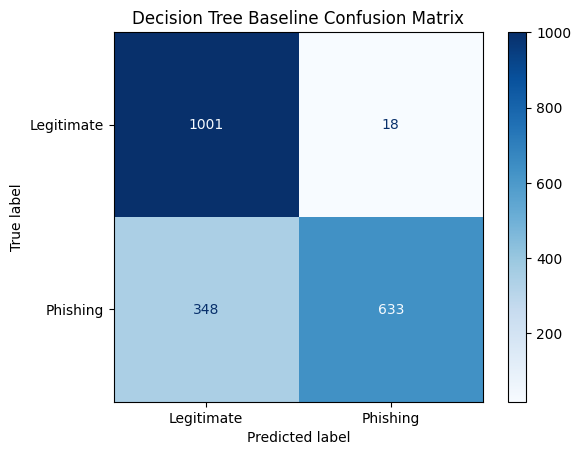

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproduce the Decision Tree configuration used by the source
tree = DecisionTreeClassifier(max_depth=5)

# Train the model
tree.fit(X_train, y_train)

# Generate predictions
y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)

# Probability estimates for ranking metrics
y_test_tree_probability = tree.predict_proba(X_test)[:, 1]

# Calculate the original accuracy metric
train_accuracy_tree = accuracy_score(y_train, y_train_tree)
test_accuracy_tree = accuracy_score(y_test, y_test_tree)

print("Decision Tree baseline results")
print("------------------------------")
print(f"Training accuracy: {train_accuracy_tree:.3f}")
print(f"Testing accuracy:  {test_accuracy_tree:.3f}")

# Calculate additional cybersecurity-relevant metrics
print("\nAdditional testing metrics")
print("--------------------------")
print(f"Precision:  {precision_score(y_test, y_test_tree):.3f}")
print(f"Recall:     {recall_score(y_test, y_test_tree):.3f}")
print(f"F1-score:   {f1_score(y_test, y_test_tree):.3f}")
print(f"F2-score:   {fbeta_score(y_test, y_test_tree, beta=2):.3f}")
print(f"MCC:        {matthews_corrcoef(y_test, y_test_tree):.3f}")
print(f"ROC-AUC:    {roc_auc_score(y_test, y_test_tree_probability):.3f}")
print(
    "PR-AUC:     "
    f"{average_precision_score(y_test, y_test_tree_probability):.3f}"
)

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_tree,
    display_labels=["Legitimate", "Phishing"],
    cmap="Blues"
)

plt.title("Decision Tree Baseline Confusion Matrix")
plt.show()

## Evaluation Metrics

This project addresses a supervised binary-classification problem:

* $0$: legitimate website
* $1$: phishing website

A phishing detector should identify malicious websites while avoiding unnecessary
blocking of legitimate websites. Accuracy alone is not sufficient, especially
when the class distribution changes after duplicate removal. Therefore, several
complementary metrics are used.

### Confusion-Matrix Terms

The confusion matrix contains four values:

| Term | Meaning in this project |
| --- | --- |
| True Positive — TP | A phishing website is correctly detected |
| True Negative — TN | A legitimate website is correctly allowed |
| False Positive — FP | A legitimate website is incorrectly blocked |
| False Negative — FN | A phishing website is incorrectly allowed |

False Positives may disrupt legitimate browsing, block valid services, and reduce
user trust in the detector. False Negatives are also dangerous because they may
allow users to reach malicious pages and disclose credentials or other sensitive
information.

### Accuracy

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

Accuracy measures the proportion of correctly classified observations. It is
easy to interpret, but it can be misleading when one class dominates the
dataset. For example, after duplicate removal, a model can achieve high accuracy
by predicting almost every website as phishing.

### Precision

$$\text{Precision} = \frac{TP}{TP + FP}$$

Precision measures how trustworthy a phishing warning is. High precision means
that when the model classifies a website as phishing, it is usually correct.
Low precision indicates that many legitimate websites are blocked unnecessarily.

### Recall

$$\text{Recall} = \frac{TP}{TP + FN}$$

Recall, also called sensitivity or the True Positive Rate, measures the
percentage of phishing websites that are detected. High recall is important
because a False Negative may expose a user to credential theft or malicious
content.

### Specificity

$$\text{Specificity} = \frac{TN}{TN + FP}$$

Specificity measures the percentage of legitimate websites that are correctly
allowed. It is especially important when the system blocks websites
automatically. A detector with low specificity may interrupt normal browsing
even if it detects many phishing websites.

### False Positive Rate

$$\text{False Positive Rate} = \frac{FP}{FP + TN} = 1 - \text{Specificity}$$

The False Positive Rate measures the proportion of legitimate websites that are
incorrectly blocked. It is used during threshold analysis to quantify the cost
of increasing phishing sensitivity.

### Balanced Accuracy

$$\text{Balanced Accuracy} = \frac{\text{Recall} + \text{Specificity}}{2}$$

Balanced accuracy gives equal importance to the phishing and legitimate classes.
It is useful after duplicate removal because the remaining unique observations
are strongly imbalanced.

### F1 Score

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

The F1 score is the harmonic mean of precision and recall. It is useful when both
False Positives and False Negatives matter.

### F-Beta Score and F2 Score

$$F_{\beta} = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

This notebook uses $F_2$, where $\beta = 2$. The F2 score gives more weight
to recall than to precision. This is relevant because missed phishing websites
can expose users to direct security risks.

### Matthews Correlation Coefficient — MCC

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP + FP)(TP + FN)(TN + FP)(TN + FN)}}$$

MCC considers all four entries in the confusion matrix. Its value ranges from
$-1$ to $1$:

* $1$: perfect classification
* $0$: performance similar to random or majority-class prediction
* $-1$: complete disagreement

MCC is particularly useful when the classes are imbalanced. It is used as the
primary threshold-selection criterion in this project.

### ROC-AUC

The Receiver Operating Characteristic curve plots:

$$\text{True Positive Rate}$$

against:

$$\text{False Positive Rate}$$

across classification thresholds.

ROC-AUC measures the model's ability to rank phishing websites above legitimate
websites. A value of `0.5` indicates random ranking, while a value of `1.0`
indicates perfect ranking. ROC-AUC is useful for comparing models independently
of one fixed threshold, but it does not determine whether the selected operating
threshold is practical.

### Average Precision — AP

Average Precision summarizes the precision-recall relationship across
classification thresholds. It is calculated using
`average_precision_score(...)`.

AP is included because precision and recall are particularly important in
phishing detection and because class imbalance can make accuracy misleading.
AP should not be interpreted as identical to a single-threshold precision value.

### Metric Selection

Classification metrics are used because the target variable is binary. Regression
metrics such as MAE, MSE, RMSE, and $R^2$ are not applicable because the goal
is not to predict a continuous value.

The project evaluates supervised classifiers rather than unsupervised anomaly-
detection models. Therefore, anomaly-specific evaluation is not treated as a
separate experimental setting.

No single metric is treated as sufficient. Accuracy is reported for comparison
with the original source, while recall, specificity, balanced accuracy, MCC,
ROC-AUC, Average Precision, and the confusion matrix are used to assess whether
the detector would be meaningful in practice.

## Reusable Classification Evaluation Function

The following helper function evaluates each classifier consistently using
accuracy and additional cybersecurity-relevant metrics. It also displays a
confusion matrix and stores the results for later comparison.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Store the baseline results in one place for later comparison.
baseline_results = []


def evaluate_classifier(
    model_name,
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    display_confusion_matrix=True
):
    """
    Evaluate a trained binary classifier consistently.

    Label interpretation:
        0 = legitimate website
        1 = phishing website

    Returns:
        A dictionary containing the evaluation metrics.
    """

    y_train_prediction = model.predict(X_train)
    y_test_prediction = model.predict(X_test)

    # Use probability estimates when available.
    # Otherwise, use the decision-function scores.
    if hasattr(model, "predict_proba"):
        y_test_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_test_score = model.decision_function(X_test)
    else:
        y_test_score = None

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_test_prediction,
        labels=[0, 1]
    ).ravel()

    result = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(
            y_train,
            y_train_prediction
        ),
        "Test Accuracy": accuracy_score(
            y_test,
            y_test_prediction
        ),
        "Precision": precision_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        "F2": fbeta_score(
            y_test,
            y_test_prediction,
            beta=2,
            zero_division=0
        ),
        "MCC": matthews_corrcoef(
            y_test,
            y_test_prediction
        ),
        "ROC-AUC": (
            roc_auc_score(y_test, y_test_score)
            if y_test_score is not None
            else np.nan
        ),
        "PR-AUC": (
            average_precision_score(y_test, y_test_score)
            if y_test_score is not None
            else np.nan
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    # Replace an earlier result when the same cell is executed again.
    baseline_results[:] = [
        existing_result
        for existing_result in baseline_results
        if existing_result["Model"] != model_name
    ]

    baseline_results.append(result)

    print(f"{model_name} results")
    print("-" * (len(model_name) + 8))
    display(pd.DataFrame([result]).round(3))

    if display_confusion_matrix:
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_test_prediction,
            labels=[0, 1],
            display_labels=["Legitimate", "Phishing"],
            cmap="Blues"
        )

        plt.title(f"{model_name} Confusion Matrix")
        plt.show()

    return result

Decision Tree results
---------------------


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Decision Tree,0.812,0.817,0.972,0.645,0.776,0.692,0.67,0.845,0.853,1001,18,348,633


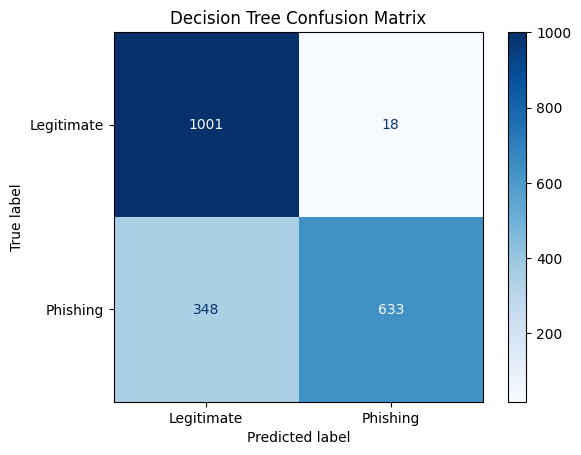

In [ ]:
decision_tree_result = evaluate_classifier(
    model_name="Decision Tree",
    model=tree,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

## Original Random Forest Baseline

The original source trains a Random Forest classifier with a maximum tree depth
of 5. The configuration is reproduced without adding parameters that were not
specified by the author.

Random Forest parameters used in the current environment:
n_estimators: 100
max_depth: 5
random_state: None
Random Forest results
---------------------


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Random Forest,0.81,0.822,0.983,0.647,0.781,0.695,0.68,0.88,0.907,1008,11,346,635


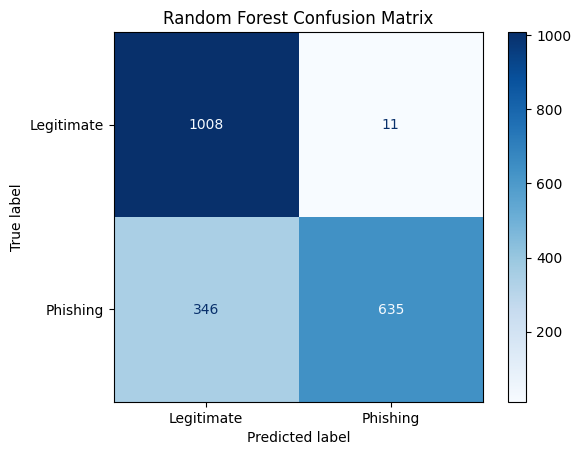

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Match the configuration used by the original source.
forest = RandomForestClassifier(max_depth=5)

forest.fit(X_train, y_train)

print("Random Forest parameters used in the current environment:")
print("n_estimators:", forest.n_estimators)
print("max_depth:", forest.max_depth)
print("random_state:", forest.random_state)

random_forest_result = evaluate_classifier(
    model_name="Random Forest",
    model=forest,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

In [ ]:
baseline_results_table = (
    pd.DataFrame(baseline_results)
    .sort_values(
        by=["Test Accuracy", "Recall"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(baseline_results_table.round(3))

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Random Forest,0.810,0.822,0.983,0.647,0.781,0.695,0.68,0.880,0.907,1008,11,346,635
1,Decision Tree,0.812,0.817,0.972,0.645,0.776,0.692,0.67,0.845,0.853,1001,18,348,633


## Tree-Based Feature Importance

Decision Trees and Random Forests provide feature-importance values that estimate
how useful each predictor was when splitting the training data.

These values do not prove causation. However, they help identify which extracted
features contribute most strongly to the tree-based models.

In [ ]:
# Compare feature importance values from the tree-based models
feature_importance_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Decision Tree Importance": tree.feature_importances_,
    "Random Forest Importance": forest.feature_importances_
})

feature_importance_table = (
    feature_importance_table
    .sort_values(
        by="Random Forest Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_importance_table.round(4))

,Feature,Decision Tree Importance,Random Forest Importance
0,URL_Length,0.6224,0.5888
1,Prefix/Suffix,0.1689,0.1714
2,URL_Depth,0.1006,0.1256
3,Have_At,0.0415,0.0351
4,iFrame,0.0253,0.0154
5,Web_Traffic,0.0329,0.0149
6,Domain_Age,0.0006,0.0132
7,Web_Forwards,0.0000,0.0099
8,TinyURL,0.0000,0.0067
9,Have_IP,0.0078,0.0060


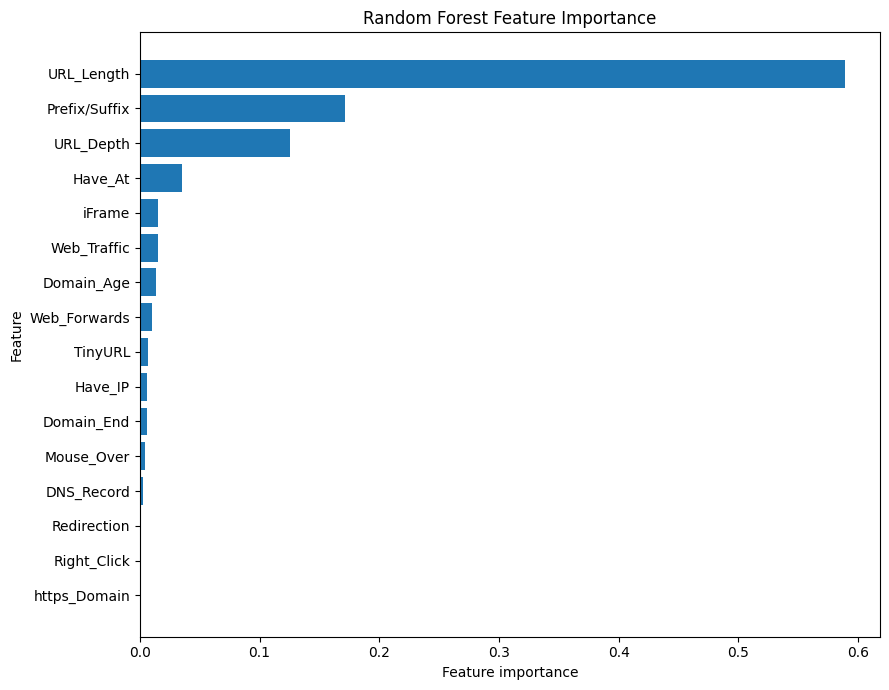

In [ ]:
# Plot Random Forest feature importance values
plot_data = feature_importance_table.sort_values(
    by="Random Forest Importance",
    ascending=True
)

plt.figure(figsize=(9, 7))
plt.barh(
    plot_data["Feature"],
    plot_data["Random Forest Importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## Feature-Level EDA

The following analysis examines the numerical predictors used by the original
models. It checks the number of distinct values, identifies constant or duplicated
columns, and compares feature distributions between legitimate and phishing
observations.

In [ ]:
# Numerical predictors used by the original models
feature_columns = [
    column
    for column in data0.columns
    if column not in ["Domain", "Label"]
]

# ---------------------------------------------------------
# 1. Summarize each predictor
# ---------------------------------------------------------
feature_summary = pd.DataFrame({
    "Feature": feature_columns,
    "Data type": [data0[column].dtype for column in feature_columns],
    "Unique values": [
        data0[column].nunique()
        for column in feature_columns
    ],
    "Minimum": [
        data0[column].min()
        for column in feature_columns
    ],
    "Maximum": [
        data0[column].max()
        for column in feature_columns
    ],
    "Mean": [
        data0[column].mean()
        for column in feature_columns
    ]
})

print("Feature summary:")
display(feature_summary.round(3))

# ---------------------------------------------------------
# 2. Identify constant columns
# ---------------------------------------------------------
constant_features = [
    column
    for column in feature_columns
    if data0[column].nunique() == 1
]

print("\nConstant features:")
if constant_features:
    print(constant_features)
else:
    print("No constant numerical features were found.")

# ---------------------------------------------------------
# 3. Identify columns containing identical values
# ---------------------------------------------------------
duplicated_feature_pairs = []

for first_index, first_feature in enumerate(feature_columns):
    for second_feature in feature_columns[first_index + 1:]:
        if data0[first_feature].equals(data0[second_feature]):
            duplicated_feature_pairs.append(
                (first_feature, second_feature)
            )

print("\nPairs of numerical features with identical values:")
if duplicated_feature_pairs:
    for pair in duplicated_feature_pairs:
        print(pair)
else:
    print("No identical numerical feature columns were found.")

Feature summary:


,Feature,Data type,Unique values,Minimum,Maximum,Mean
0,Have_IP,int64,2,0,1,0.006
1,Have_At,int64,2,0,1,0.023
2,URL_Length,int64,2,0,1,0.773
3,URL_Depth,int64,18,0,20,3.072
4,Redirection,int64,2,0,1,0.014
5,https_Domain,int64,2,0,1,0.000
6,TinyURL,int64,2,0,1,0.090
7,Prefix/Suffix,int64,2,0,1,0.093
8,DNS_Record,int64,2,0,1,0.101
9,Web_Traffic,int64,2,0,1,0.846



Constant features:
No constant numerical features were found.

Pairs of numerical features with identical values:
No identical numerical feature columns were found.


In [ ]:
# ---------------------------------------------------------
# Compare feature values between the two classes
# ---------------------------------------------------------

class_comparison = (
    data0
    .groupby("Label")[feature_columns]
    .mean()
    .transpose()
)

class_comparison.columns = [
    "Legitimate mean (Label 0)",
    "Phishing mean (Label 1)"
]

class_comparison["Absolute difference"] = (
    class_comparison["Phishing mean (Label 1)"]
    - class_comparison["Legitimate mean (Label 0)"]
).abs()

class_comparison = (
    class_comparison
    .sort_values(
        by="Absolute difference",
        ascending=False
    )
)

print("Average feature values grouped by class:")
display(class_comparison.round(3))

Average feature values grouped by class:


,Legitimate mean (Label 0),Phishing mean (Label 1),Absolute difference
URL_Depth,3.327,2.817,0.510
URL_Length,1.000,0.547,0.453
Prefix/Suffix,0.005,0.181,0.176
Domain_Age,0.456,0.372,0.084
Web_Traffic,0.885,0.806,0.079
iFrame,0.063,0.119,0.057
Domain_End,0.837,0.783,0.054
TinyURL,0.069,0.111,0.042
Have_At,0.005,0.040,0.035
Mouse_Over,0.054,0.079,0.026


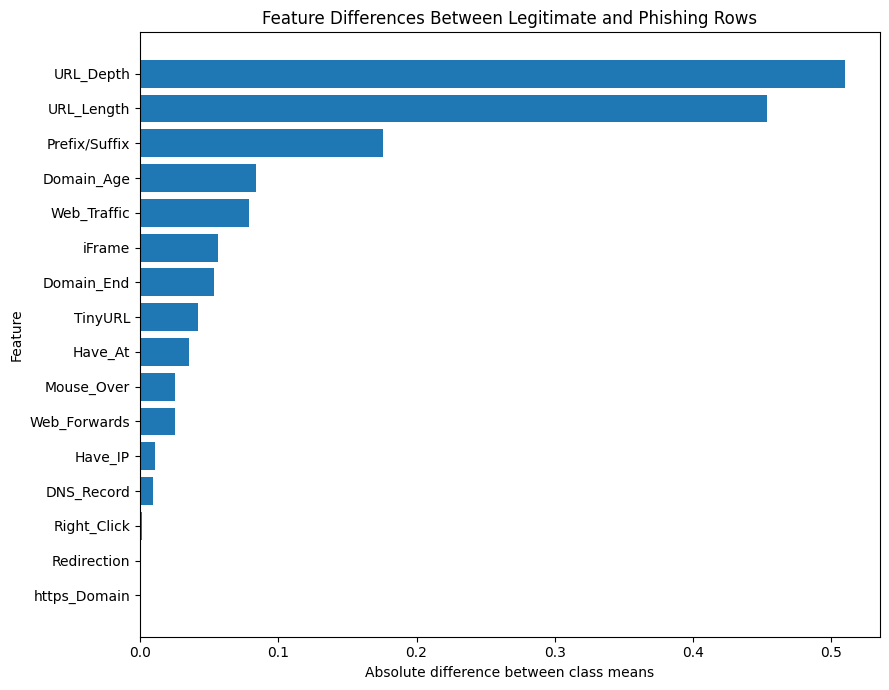

In [ ]:
# ---------------------------------------------------------
# Visualize the differences between the classes
# ---------------------------------------------------------

plot_data = (
    class_comparison
    .sort_values(
        by="Absolute difference",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))
plt.barh(
    plot_data.index,
    plot_data["Absolute difference"]
)

plt.xlabel("Absolute difference between class means")
plt.ylabel("Feature")
plt.title("Feature Differences Between Legitimate and Phishing Rows")
plt.tight_layout()
plt.show()

### Exact Feature Prevalence and Direction of Association

The previous plot used absolute differences. The following tables preserve the
direction of each difference and identify predictors with very low variation.

In [ ]:
# Binary predictors only
binary_features = [
    column
    for column in feature_columns
    if data0[column].nunique() == 2
]

# Count and percentage of rows receiving value 1 in each class
binary_prevalence = pd.DataFrame({
    "Legitimate count of 1": (
        data0.loc[data0["Label"] == 0, binary_features]
        .sum()
    ),
    "Legitimate percentage of 1": (
        100 * data0.loc[data0["Label"] == 0, binary_features]
        .mean()
    ),
    "Phishing count of 1": (
        data0.loc[data0["Label"] == 1, binary_features]
        .sum()
    ),
    "Phishing percentage of 1": (
        100 * data0.loc[data0["Label"] == 1, binary_features]
        .mean()
    )
})

binary_prevalence["Signed difference: phishing - legitimate"] = (
    binary_prevalence["Phishing percentage of 1"]
    - binary_prevalence["Legitimate percentage of 1"]
)

binary_prevalence = binary_prevalence.sort_values(
    by="Signed difference: phishing - legitimate",
    ascending=False
)

display(binary_prevalence.round(3))

,Legitimate count of 1,Legitimate percentage of 1,Phishing count of 1,Phishing percentage of 1,Signed difference: phishing - legitimate
Prefix/Suffix,26,0.52,906,18.12,17.60
iFrame,313,6.26,596,11.92,5.66
TinyURL,347,6.94,556,11.12,4.18
Have_At,25,0.50,201,4.02,3.52
Mouse_Over,269,5.38,397,7.94,2.56
Have_IP,0,0.00,55,1.10,1.10
DNS_Record,480,9.60,528,10.56,0.96
Redirection,66,1.32,69,1.38,0.06
https_Domain,0,0.00,2,0.04,0.04
Right_Click,5000,100.00,4993,99.86,-0.14


In [ ]:
# Identify features with very low variation
feature_variation = pd.DataFrame({
    "Feature": feature_columns,
    "Unique values": [
        data0[column].nunique()
        for column in feature_columns
    ],
    "Most common value": [
        data0[column].value_counts().index[0]
        for column in feature_columns
    ],
    "Most common value count": [
        data0[column].value_counts().iloc[0]
        for column in feature_columns
    ],
    "Most common value percentage": [
        100 * data0[column].value_counts(normalize=True).iloc[0]
        for column in feature_columns
    ]
})

feature_variation = feature_variation.sort_values(
    by="Most common value percentage",
    ascending=False
)

display(feature_variation.round(3))

print("Near-constant features: more than 99% of rows share one value")
display(
    feature_variation.loc[
        feature_variation["Most common value percentage"] > 99
    ].round(3)
)

,Feature,Unique values,Most common value,Most common value count,Most common value percentage
5,https_Domain,2,0,9998,99.98
14,Right_Click,2,1,9993,99.93
0,Have_IP,2,0,9945,99.45
4,Redirection,2,0,9865,98.65
1,Have_At,2,0,9774,97.74
13,Mouse_Over,2,0,9334,93.34
6,TinyURL,2,0,9097,90.97
12,iFrame,2,0,9091,90.91
7,Prefix/Suffix,2,0,9068,90.68
8,DNS_Record,2,0,8992,89.92


Near-constant features: more than 99% of rows share one value


,Feature,Unique values,Most common value,Most common value count,Most common value percentage
5,https_Domain,2,0,9998,99.98
14,Right_Click,2,1,9993,99.93
0,Have_IP,2,0,9945,99.45


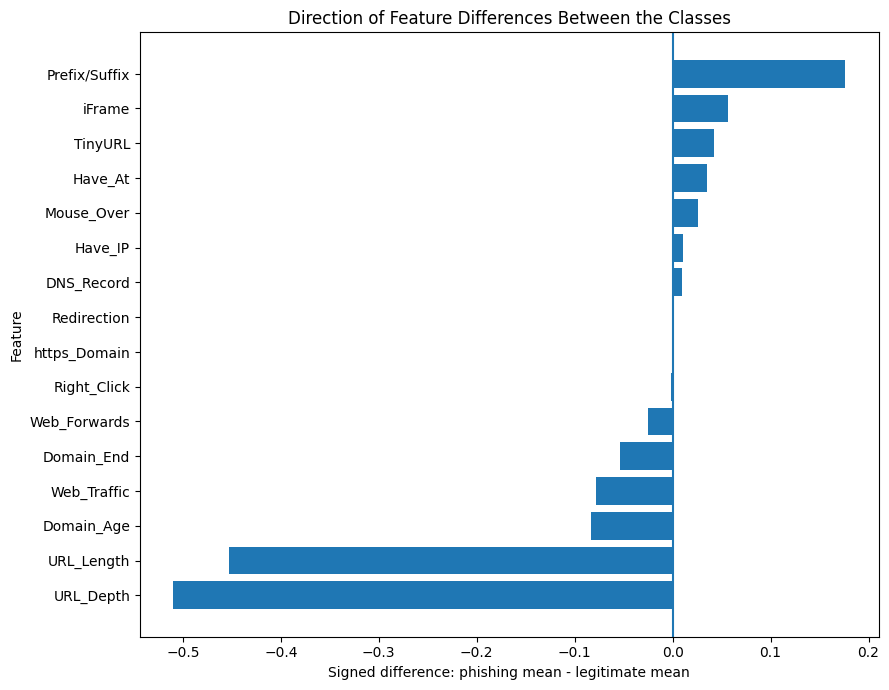

In [ ]:
# Plot signed differences rather than absolute differences
signed_plot_data = (
    class_comparison
    .assign(
        **{
            "Signed difference: phishing - legitimate":
            (
                class_comparison["Phishing mean (Label 1)"]
                - class_comparison["Legitimate mean (Label 0)"]
            )
        }
    )
    .sort_values(
        by="Signed difference: phishing - legitimate",
        ascending=True
    )
)

plt.figure(figsize=(9, 7))
plt.barh(
    signed_plot_data.index,
    signed_plot_data["Signed difference: phishing - legitimate"]
)

plt.axvline(0)
plt.xlabel("Signed difference: phishing mean - legitimate mean")
plt.ylabel("Feature")
plt.title("Direction of Feature Differences Between the Classes")
plt.tight_layout()

plt.savefig(
    "feature_difference_direction.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Controlled Audit of the Feature-Extraction Script

The supplied Python script is inspected using controlled examples. These tests
do not contact external websites. Their purpose is to check whether selected
features behave consistently with their written descriptions.

In [ ]:
import importlib
import inspect
import URLFeatureExtraction as feature_extractor

# Reload the module after upload
feature_extractor = importlib.reload(feature_extractor)

print(
    "Does the module expose getDomain?",
    hasattr(feature_extractor, "getDomain")
)

print(
    "Does the module expose whois?",
    hasattr(feature_extractor, "whois")
)

print(
    "featureExtraction signature:",
    inspect.signature(feature_extractor.featureExtraction)
)

print(
    "Number of declared feature names:",
    len(feature_extractor.feature_names)
)

print("\nDeclared feature names:")
print(feature_extractor.feature_names)

Does the module expose getDomain? False
Does the module expose whois? False
featureExtraction signature: (url)
Number of declared feature names: 18

Declared feature names:
['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label']


In [ ]:
from urllib.parse import urlparse
import ipaddress
import pandas as pd


def corrected_having_ip(url):
    """
    Extract the hostname first and check whether the hostname is an IP address.
    This is used only for comparison with the original implementation.
    """
    parsed_url = urlparse(url)

    hostname = parsed_url.hostname

    if hostname is None:
        hostname = url

    try:
        ipaddress.ip_address(hostname)
        return 1
    except ValueError:
        return 0


ip_test_urls = [
    "192.168.1.10",
    "http://192.168.1.10/login",
    "https://8.8.8.8/account",
    "https://example.com/login"
]

ip_test_results = pd.DataFrame({
    "URL": ip_test_urls,
    "Original havingIP()": [
        feature_extractor.havingIP(url)
        for url in ip_test_urls
    ],
    "Hostname-aware comparison": [
        corrected_having_ip(url)
        for url in ip_test_urls
    ]
})

display(ip_test_results)

,URL,Original havingIP(),Hostname-aware comparison
0,192.168.1.10,1,1
1,http://192.168.1.10/login,0,1
2,https://8.8.8.8/account,0,1
3,https://example.com/login,0,0


In [ ]:
length_test_values = [
    "a" * 53,
    "a" * 54,
    "a" * 80
]

length_test_results = pd.DataFrame({
    "Raw URL length": [
        len(value)
        for value in length_test_values
    ],
    "Extracted URL_Length value": [
        feature_extractor.getLength(value)
        for value in length_test_values
    ]
})

display(length_test_results)

,Raw URL length,Extracted URL_Length value
0,53,0
1,54,1
2,80,1


In [ ]:
class FakeResponse:
    """
    Minimal response-like object used for controlled tests.
    """
    def __init__(self, text="", history=None):
        self.text = text
        self.history = [] if history is None else history


plain_html_response = FakeResponse(
    text="<html><body>Hello world</body></html>"
)

iframe_response = FakeResponse(
    text="<html><body><iframe src='page.html'></iframe></body></html>"
)

normal_script_response = FakeResponse(
    text="<script>console.log('normal page');</script>"
)

disabled_right_click_response = FakeResponse(
    text="<script>if (event.button == 2) { return false; }</script>"
)

html_feature_tests = pd.DataFrame({
    "Test case": [
        "Plain HTML without iframe",
        "HTML containing iframe",
        "Normal script without right-click blocking",
        "Script containing event.button == 2"
    ],
    "iframe() result": [
        feature_extractor.iframe(plain_html_response),
        feature_extractor.iframe(iframe_response),
        None,
        None
    ],
    "rightClick() result": [
        None,
        None,
        feature_extractor.rightClick(normal_script_response),
        feature_extractor.rightClick(
            disabled_right_click_response
        )
    ]
})

display(html_feature_tests)

,Test case,iframe() result,rightClick() result
0,Plain HTML without iframe,0.0,NaN
1,HTML containing iframe,0.0,NaN
2,Normal script without right-click blocking,NaN,1.0
3,Script containing event.button == 2,NaN,0.0


### Standalone Script Consistency Check

The following controlled test avoids network calls. It checks the number of
features returned by the standalone extraction function and examines the
behavior of domain-related predictors when the WHOIS dependency is unavailable.

In [ ]:
# Save the original functions before temporarily replacing network calls
original_web_traffic = feature_extractor.web_traffic
original_requests_get = feature_extractor.requests.get

try:
    # Avoid external network calls during the controlled test
    feature_extractor.web_traffic = lambda url: 0
    feature_extractor.requests.get = lambda url: FakeResponse(
        text="<html><body>Example page</body></html>",
        history=[]
    )

    controlled_url = "https://example.com/login"

    extracted_values = feature_extractor.featureExtraction(
        controlled_url
    )

finally:
    # Restore the original implementations
    feature_extractor.web_traffic = original_web_traffic
    feature_extractor.requests.get = original_requests_get


standalone_numeric_feature_names = (
    feature_extractor.feature_names[1:-1]
)

controlled_extraction_table = pd.DataFrame(
    [extracted_values],
    columns=standalone_numeric_feature_names
)

print("Number of declared columns:", len(feature_extractor.feature_names))
print("Number of returned numerical values:", len(extracted_values))

print("\nControlled extraction result:")
display(controlled_extraction_table)

print("\nDomain-related values:")
display(
    controlled_extraction_table[
        [
            "DNS_Record",
            "Web_Traffic",
            "Domain_Age",
            "Domain_End"
        ]
    ]
)

print("\nAttempt to combine the returned values with all declared columns:")

try:
    pd.DataFrame(
        [extracted_values],
        columns=feature_extractor.feature_names
    )

except ValueError as error:
    print("ValueError:", error)

Number of declared columns: 18
Number of returned numerical values: 16

Controlled extraction result:


,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards
0,0,0,0,1,0,0,0,0,1,0,1,1,0,0,1,0



Domain-related values:


,DNS_Record,Web_Traffic,Domain_Age,Domain_End
0,1,0,1,1



Attempt to combine the returned values with all declared columns:
ValueError: 18 columns passed, passed data had 16 columns


## Original XGBoost Baseline

The original source reports that XGBoost achieved the highest testing accuracy.
The following experiment reproduces the original configuration using the
contaminated random split preserved from the source.

The results are interpreted as a baseline reproduction only. Later experiments
will evaluate the model using stricter and fully reproducible splits.

In [ ]:
# Install XGBoost only if it is unavailable in the current environment.
# Google Colab normally includes it already.
try:
    import xgboost
    from xgboost import XGBClassifier
except ImportError:
    !pip install -q xgboost
    import xgboost
    from xgboost import XGBClassifier

print("XGBoost version:", xgboost.__version__)

XGBoost version: 3.2.0


In [ ]:
# Reproduce the configuration used by the original source.
#
# The original notebook specifies:
#   learning_rate = 0.4
#   max_depth = 7
#
# Other parameters use the defaults of the installed XGBoost version.
xgb = XGBClassifier(
    learning_rate=0.4,
    max_depth=7,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

print("Selected XGBoost parameters:")
print("learning_rate:", xgb.learning_rate)
print("max_depth:", xgb.max_depth)
print("n_estimators:", xgb.n_estimators)
print("random_state:", xgb.random_state)

Selected XGBoost parameters:
learning_rate: 0.4
max_depth: 7
n_estimators: None
random_state: None


XGBoost results
---------------


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,XGBoost,0.867,0.863,0.912,0.798,0.851,0.819,0.731,0.918,0.936,943,76,198,783


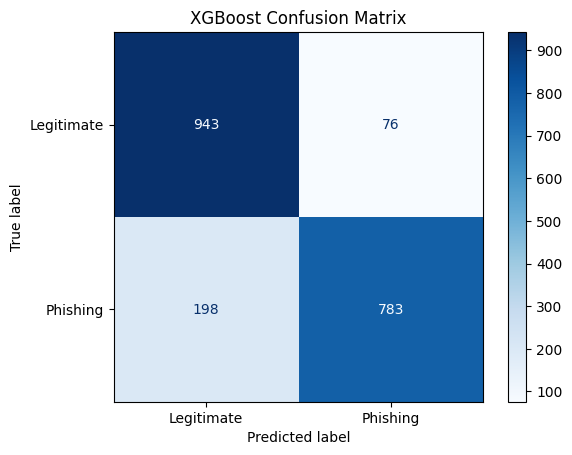

In [ ]:
xgboost_result = evaluate_classifier(
    model_name="XGBoost",
    model=xgb,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

In [ ]:
baseline_results_table = (
    pd.DataFrame(baseline_results)
    .sort_values(
        by=["Test Accuracy", "Recall"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(baseline_results_table.round(3))

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,XGBoost,0.867,0.863,0.912,0.798,0.851,0.819,0.731,0.918,0.936,943,76,198,783
1,Random Forest,0.810,0.822,0.983,0.647,0.781,0.695,0.680,0.880,0.907,1008,11,346,635
2,Decision Tree,0.812,0.817,0.972,0.645,0.776,0.692,0.670,0.845,0.853,1001,18,348,633


In [ ]:
# Check the effective number of boosting rounds used by the fitted model
effective_boosting_rounds = xgb.get_booster().num_boosted_rounds()

print("Effective number of boosting rounds:", effective_boosting_rounds)

Effective number of boosting rounds: 100


In [ ]:
# Save the current baseline results before modifying the experiment
baseline_results_table.to_csv(
    "baseline_results_original_random_split.csv",
    index=False
)

print("Saved: baseline_results_original_random_split.csv")

Saved: baseline_results_original_random_split.csv


# Controlled Experiments

## Controlled Random Split with Fixed Seeds

The original random-split experiment can vary between executions because the
initial shuffle and several model configurations do not define fixed random seeds.

The following split remains comparable to the original methodology but improves
reproducibility by using:
- a fixed random seed;
- stratification by the target label;
- explicit model seeds;
- an explicit number of estimators.

Duplicated observations are intentionally retained at this stage. A later
experiment evaluates the effect of removing them.

In [ ]:
from sklearn.model_selection import train_test_split

# Predictors used by the original classifiers
feature_columns = [
    column
    for column in data0.columns
    if column not in ["Domain", "Label"]
]

# Fully reproducible random split.
# No additional shuffle is needed because train_test_split shuffles by default.
controlled_train_full, controlled_test_full = train_test_split(
    data0,
    test_size=0.20,
    random_state=42,
    stratify=data0["Label"]
)

X_train_controlled = controlled_train_full[feature_columns]
X_test_controlled = controlled_test_full[feature_columns]

y_train_controlled = controlled_train_full["Label"]
y_test_controlled = controlled_test_full["Label"]

print("Controlled training shape:", X_train_controlled.shape)
print("Controlled testing shape:", X_test_controlled.shape)

print("\nControlled training-label distribution:")
print(y_train_controlled.value_counts().sort_index())

print("\nControlled testing-label distribution:")
print(y_test_controlled.value_counts().sort_index())

Controlled training shape: (8000, 16)
Controlled testing shape: (2000, 16)

Controlled training-label distribution:
Label
0    4000
1    4000
Name: count, dtype: int64

Controlled testing-label distribution:
Label
0    1000
1    1000
Name: count, dtype: int64


In [ ]:
def calculate_row_hashes(frame):
    """
    Calculate stable hashes for DataFrame rows.
    Identical rows receive identical hash values.
    """
    return pd.util.hash_pandas_object(
        frame,
        index=False
    )


# Exact complete-row overlap
controlled_train_complete_hashes = set(
    calculate_row_hashes(controlled_train_full)
)

controlled_test_complete_hashes = calculate_row_hashes(
    controlled_test_full
)

controlled_exact_overlap = (
    controlled_test_complete_hashes
    .isin(controlled_train_complete_hashes)
    .sum()
)


# Domain overlap
controlled_training_domains = set(
    controlled_train_full["Domain"]
)

controlled_domain_overlap = (
    controlled_test_full["Domain"]
    .isin(controlled_training_domains)
    .sum()
)

controlled_overlapping_domain_names = (
    set(controlled_train_full["Domain"])
    .intersection(
        set(controlled_test_full["Domain"])
    )
)


# Numerical feature-vector overlap
controlled_train_feature_hashes = set(
    calculate_row_hashes(
        controlled_train_full[feature_columns]
    )
)

controlled_test_feature_hashes = calculate_row_hashes(
    controlled_test_full[feature_columns]
)

controlled_feature_overlap = (
    controlled_test_feature_hashes
    .isin(controlled_train_feature_hashes)
    .sum()
)


print("Total controlled test rows:", len(controlled_test_full))

print(
    "Test rows identical to a complete training row:",
    controlled_exact_overlap
)

print(
    "Test rows whose domain also appears in training:",
    controlled_domain_overlap
)

print(
    "Number of domains appearing in both sets:",
    len(controlled_overlapping_domain_names)
)

print(
    "Test rows whose numerical feature vector also appears in training:",
    controlled_feature_overlap
)

Total controlled test rows: 2000
Test rows identical to a complete training row: 1272
Test rows whose domain also appears in training: 1427
Number of domains appearing in both sets: 467
Test rows whose numerical feature vector also appears in training: 1923


In [ ]:
# Check how many boosting rounds were used by the previously fitted
# XGBoost baseline, because the source did not specify n_estimators explicitly.
effective_boosting_rounds = xgb.get_booster().num_boosted_rounds()

print(
    "Effective number of boosting rounds used by the original-style XGBoost model:",
    effective_boosting_rounds
)

Effective number of boosting rounds used by the original-style XGBoost model: 100


## Deterministic Baseline Models on the Controlled Random Split

The following models reproduce the main baseline configurations while explicitly
fixing all relevant random seeds. Duplicated observations remain in the dataset
at this stage so that the results remain comparable with the original methodology.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

controlled_results = []


def evaluate_and_store_classifier(
    model_name,
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    results_store,
    display_confusion_matrix=True
):
    """
    Evaluate a binary phishing-detection classifier consistently.

    Labels:
        0 = legitimate website
        1 = phishing website
    """

    y_train_prediction = model.predict(X_train)
    y_test_prediction = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_test_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_test_score = model.decision_function(X_test)
    else:
        y_test_score = None

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_test_prediction,
        labels=[0, 1]
    ).ravel()

    result = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(
            y_train,
            y_train_prediction
        ),
        "Test Accuracy": accuracy_score(
            y_test,
            y_test_prediction
        ),
        "Precision": precision_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        "F2": fbeta_score(
            y_test,
            y_test_prediction,
            beta=2,
            zero_division=0
        ),
        "MCC": matthews_corrcoef(
            y_test,
            y_test_prediction
        ),
        "ROC-AUC": (
            roc_auc_score(y_test, y_test_score)
            if y_test_score is not None
            else np.nan
        ),
        "PR-AUC": (
            average_precision_score(y_test, y_test_score)
            if y_test_score is not None
            else np.nan
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    # Replace an earlier result if the same model cell is rerun.
    results_store[:] = [
        previous_result
        for previous_result in results_store
        if previous_result["Model"] != model_name
    ]

    results_store.append(result)

    print(f"{model_name} results")
    print("-" * (len(model_name) + 8))
    display(pd.DataFrame([result]).round(3))

    if display_confusion_matrix:
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_test_prediction,
            labels=[0, 1],
            display_labels=["Legitimate", "Phishing"],
            cmap="Blues"
        )

        plt.title(f"{model_name} — Controlled Random Split")
        plt.show()

    return result

Decision Tree results
---------------------


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Decision Tree,0.814,0.81,0.973,0.638,0.771,0.685,0.66,0.851,0.859,982,18,362,638


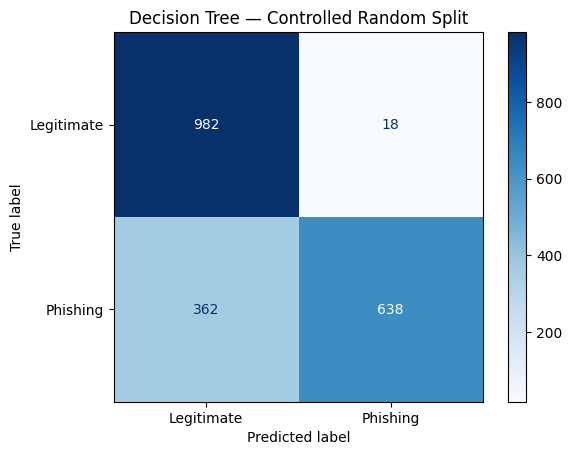

In [ ]:
from sklearn.tree import DecisionTreeClassifier

controlled_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

controlled_tree.fit(
    X_train_controlled,
    y_train_controlled
)

controlled_tree_result = evaluate_and_store_classifier(
    model_name="Decision Tree",
    model=controlled_tree,
    X_train=X_train_controlled,
    y_train=y_train_controlled,
    X_test=X_test_controlled,
    y_test=y_test_controlled,
    results_store=controlled_results
)

Random Forest results
---------------------


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Random Forest,0.82,0.818,0.98,0.649,0.781,0.696,0.676,0.887,0.913,987,13,351,649


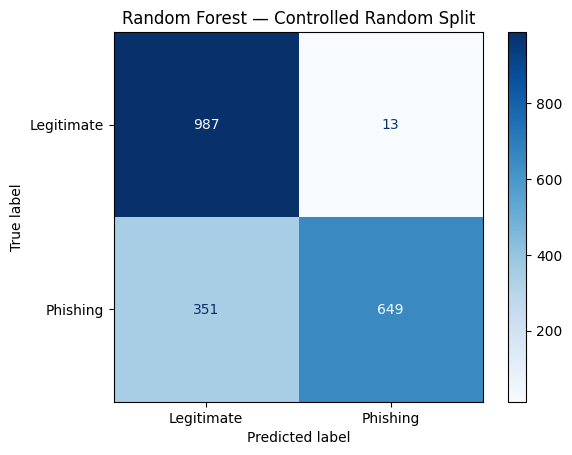

In [ ]:
from sklearn.ensemble import RandomForestClassifier

controlled_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

controlled_forest.fit(
    X_train_controlled,
    y_train_controlled
)

controlled_forest_result = evaluate_and_store_classifier(
    model_name="Random Forest",
    model=controlled_forest,
    X_train=X_train_controlled,
    y_train=y_train_controlled,
    X_test=X_test_controlled,
    y_test=y_test_controlled,
    results_store=controlled_results
)

XGBoost results
---------------


,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,XGBoost,0.866,0.866,0.928,0.795,0.856,0.818,0.741,0.926,0.943,938,62,205,795


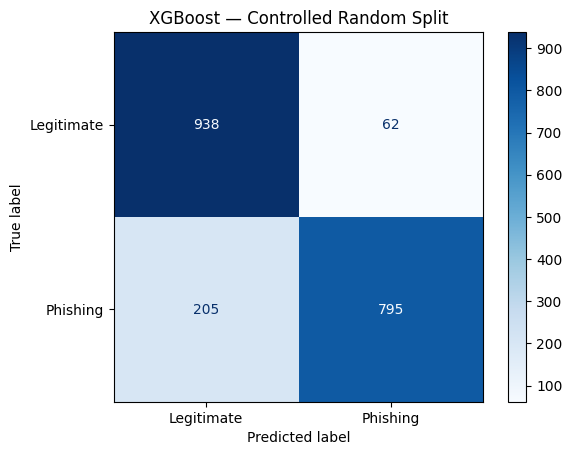

In [ ]:
from xgboost import XGBClassifier

controlled_xgb = XGBClassifier(
    learning_rate=0.4,
    max_depth=7,
    n_estimators=effective_boosting_rounds,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

controlled_xgb.fit(
    X_train_controlled,
    y_train_controlled
)

controlled_xgb_result = evaluate_and_store_classifier(
    model_name="XGBoost",
    model=controlled_xgb,
    X_train=X_train_controlled,
    y_train=y_train_controlled,
    X_test=X_test_controlled,
    y_test=y_test_controlled,
    results_store=controlled_results
)

In [ ]:
controlled_results_table = (
    pd.DataFrame(controlled_results)
    .sort_values(
        by=["Test Accuracy", "Recall"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(controlled_results_table.round(3))

controlled_results_table.to_csv(
    "controlled_random_split_results.csv",
    index=False
)

print("Saved: controlled_random_split_results.csv")

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,XGBoost,0.866,0.866,0.928,0.795,0.856,0.818,0.741,0.926,0.943,938,62,205,795
1,Random Forest,0.820,0.818,0.980,0.649,0.781,0.696,0.676,0.887,0.913,987,13,351,649
2,Decision Tree,0.814,0.810,0.973,0.638,0.771,0.685,0.660,0.851,0.859,982,18,362,638


Saved: controlled_random_split_results.csv


# Remaining Exploratory Data Analysis

This section completes the required exploratory analysis before the stricter
evaluation experiments. The processed dataset does not include a timestamp or
collection-date column. Therefore, temporal analysis cannot be performed using
the supplied data.

The default integer index is appropriate because each row represents an
observation and no meaningful identifier is stored in the index.

In [ ]:
# ---------------------------------------------------------
# Index and temporal-column inspection
# ---------------------------------------------------------

print("Index type:", type(data0.index).__name__)
print("Index name:", data0.index.name)

possible_temporal_columns = [
    column
    for column in data0.columns
    if any(
        keyword in column.lower()
        for keyword in ["date", "time", "timestamp", "year", "month", "day"]
    )
]

print("\nPossible temporal columns:", possible_temporal_columns)

if not possible_temporal_columns:
    print(
        "No temporal columns were found. "
        "Temporal analysis is not applicable to the supplied processed dataset."
    )

Index type: RangeIndex
Index name: None

Possible temporal columns: []
No temporal columns were found. Temporal analysis is not applicable to the supplied processed dataset.


## Outlier Analysis

Most predictors are binary indicators. Traditional outlier analysis is therefore
not meaningful for those columns. `URL_Depth` is examined separately because it
is a numerical count feature with multiple possible values.

URL_Depth descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
URL_Depth,10000.0,3.072,2.128631,0.0,2.0,3.0,4.0,20.0


IQR lower bound: -1.0
IQR upper bound: 7.0
Number of URL_Depth outliers: 357


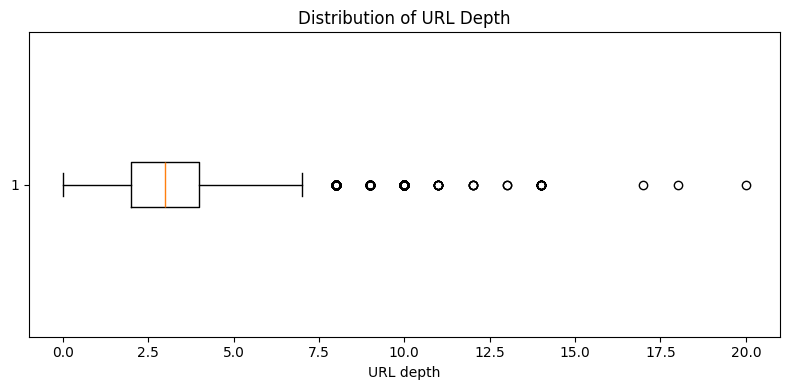

In [ ]:
# ---------------------------------------------------------
# Outlier analysis for URL_Depth
# ---------------------------------------------------------

url_depth_summary = data0["URL_Depth"].describe()

print("URL_Depth descriptive statistics:")
display(url_depth_summary.to_frame().transpose())

q1 = data0["URL_Depth"].quantile(0.25)
q3 = data0["URL_Depth"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

url_depth_outliers = data0.loc[
    (data0["URL_Depth"] < lower_bound)
    | (data0["URL_Depth"] > upper_bound)
]

print("IQR lower bound:", lower_bound)
print("IQR upper bound:", upper_bound)
print("Number of URL_Depth outliers:", len(url_depth_outliers))

plt.figure(figsize=(8, 4))
plt.boxplot(data0["URL_Depth"], vert=False)
plt.xlabel("URL depth")
plt.title("Distribution of URL Depth")
plt.tight_layout()
plt.show()

## Correlation Analysis

Most predictors are binary or ordinal indicators, and `URL_Depth` is a count
variable with a non-normal distribution. Spearman correlation is used because it
measures monotonic relationships using ranks and is less sensitive to outliers
and non-normal distributions than Pearson correlation.

Correlation does not prove causation. The analysis is used to identify possible
redundancy and relationships that deserve further interpretation.

Spearman correlations with the target label:


,Spearman correlation
URL_Length,-0.541
Prefix/Suffix,0.303
URL_Depth,-0.150
Have_At,0.118
Web_Traffic,-0.109
iFrame,0.098
Domain_Age,-0.085
Have_IP,0.074
TinyURL,0.073
Domain_End,-0.069


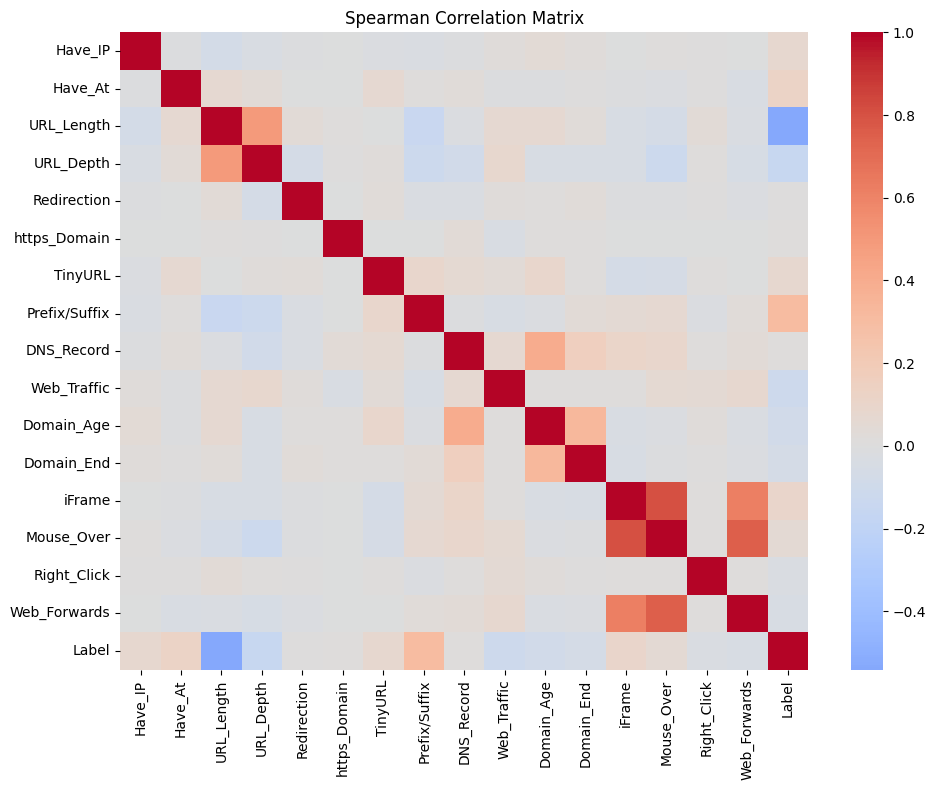

In [ ]:
# ---------------------------------------------------------
# Spearman correlation analysis
# ---------------------------------------------------------

correlation_columns = feature_columns + ["Label"]

spearman_correlation = (
    data0[correlation_columns]
    .corr(method="spearman")
)

label_correlations = (
    spearman_correlation["Label"]
    .drop("Label")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
)

print("Spearman correlations with the target label:")
display(label_correlations.to_frame("Spearman correlation").round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Identify strongly correlated predictor pairs
# ---------------------------------------------------------

strong_correlation_pairs = []

for first_index, first_feature in enumerate(feature_columns):
    for second_feature in feature_columns[first_index + 1:]:
        correlation_value = spearman_correlation.loc[
            first_feature,
            second_feature
        ]

        if abs(correlation_value) >= 0.70:
            strong_correlation_pairs.append({
                "Feature 1": first_feature,
                "Feature 2": second_feature,
                "Spearman correlation": correlation_value
            })

strong_correlation_table = pd.DataFrame(
    strong_correlation_pairs
)

if strong_correlation_table.empty:
    print(
        "No predictor pairs with an absolute Spearman correlation "
        "greater than or equal to 0.70 were found."
    )
else:
    display(
        strong_correlation_table
        .sort_values(
            by="Spearman correlation",
            key=lambda values: values.abs(),
            ascending=False
        )
        .round(3)
    )

,Feature 1,Feature 2,Spearman correlation
0,iFrame,Mouse_Over,0.807
1,Mouse_Over,Web_Forwards,0.750


# Deduplicated Dataset Experiment

The supplied dataset contains many exact duplicated rows. A random split can place
identical observations in both the training and testing sets.

This experiment removes exact duplicated rows before splitting the data. The goal
is to measure how much the baseline performance depends on repeated observations.
Repeated domains and repeated numerical feature vectors may still remain; these
will be measured explicitly and addressed later using a domain-aware split.

In [ ]:
# ---------------------------------------------------------
# Remove exact duplicated rows
# ---------------------------------------------------------

deduplicated_data = (
    data0
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Original number of rows:", len(data0))
print("Rows after exact duplicate removal:", len(deduplicated_data))
print("Removed duplicate rows:", len(data0) - len(deduplicated_data))

print("\nClass distribution after duplicate removal:")
deduplicated_class_counts = (
    deduplicated_data["Label"]
    .value_counts()
    .sort_index()
)

deduplicated_class_percentages = (
    deduplicated_data["Label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(deduplicated_class_counts)

print("\nClass percentages after duplicate removal:")
print(deduplicated_class_percentages)

Original number of rows: 10000
Rows after exact duplicate removal: 4374
Removed duplicate rows: 5626

Class distribution after duplicate removal:
Label
0     529
1    3845
Name: count, dtype: int64

Class percentages after duplicate removal:
Label
0    12.09
1    87.91
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

feature_columns = [
    column
    for column in deduplicated_data.columns
    if column not in ["Domain", "Label"]
]

deduplicated_train_full, deduplicated_test_full = train_test_split(
    deduplicated_data,
    test_size=0.20,
    random_state=42,
    stratify=deduplicated_data["Label"]
)

X_train_deduplicated = deduplicated_train_full[feature_columns]
X_test_deduplicated = deduplicated_test_full[feature_columns]

y_train_deduplicated = deduplicated_train_full["Label"]
y_test_deduplicated = deduplicated_test_full["Label"]

print("Deduplicated training shape:", X_train_deduplicated.shape)
print("Deduplicated testing shape:", X_test_deduplicated.shape)

print("\nTraining-label distribution:")
print(y_train_deduplicated.value_counts().sort_index())

print("\nTesting-label distribution:")
print(y_test_deduplicated.value_counts().sort_index())

Deduplicated training shape: (3499, 16)
Deduplicated testing shape: (875, 16)

Training-label distribution:
Label
0     423
1    3076
Name: count, dtype: int64

Testing-label distribution:
Label
0    106
1    769
Name: count, dtype: int64


In [ ]:
def audit_split_overlap(
    train_frame,
    test_frame,
    feature_columns
):
    """
    Measure overlap between training and testing data.
    """

    train_complete_hashes = set(
        pd.util.hash_pandas_object(
            train_frame,
            index=False
        )
    )

    test_complete_hashes = (
        pd.util.hash_pandas_object(
            test_frame,
            index=False
        )
    )

    exact_row_overlap = (
        test_complete_hashes
        .isin(train_complete_hashes)
        .sum()
    )

    training_domains = set(train_frame["Domain"])

    domain_overlap = (
        test_frame["Domain"]
        .isin(training_domains)
        .sum()
    )

    overlapping_domain_names = (
        set(train_frame["Domain"])
        .intersection(set(test_frame["Domain"]))
    )

    train_feature_hashes = set(
        pd.util.hash_pandas_object(
            train_frame[feature_columns],
            index=False
        )
    )

    test_feature_hashes = (
        pd.util.hash_pandas_object(
            test_frame[feature_columns],
            index=False
        )
    )

    feature_vector_overlap = (
        test_feature_hashes
        .isin(train_feature_hashes)
        .sum()
    )

    results = pd.DataFrame({
        "Check": [
            "Total test rows",
            "Exact complete-row overlap",
            "Rows with a domain also seen in training",
            "Domains appearing in both sets",
            "Rows with a numerical feature vector seen in training"
        ],
        "Value": [
            len(test_frame),
            exact_row_overlap,
            domain_overlap,
            len(overlapping_domain_names),
            feature_vector_overlap
        ]
    })

    return results


deduplicated_overlap_audit = audit_split_overlap(
    train_frame=deduplicated_train_full,
    test_frame=deduplicated_test_full,
    feature_columns=feature_columns
)

display(deduplicated_overlap_audit)

,Check,Value
0,Total test rows,875
1,Exact complete-row overlap,0
2,Rows with a domain also seen in training,232
3,Domains appearing in both sets,212
4,Rows with a numerical feature vector seen in t...,780


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


def evaluate_deduplicated_classifier(
    model_name,
    model,
    X_train,
    y_train,
    X_test,
    y_test
):
    """
    Evaluate a classifier on the deduplicated dataset.

    Labels:
        0 = legitimate website
        1 = phishing website
    """

    y_train_prediction = model.predict(X_train)
    y_test_prediction = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_test_score = model.predict_proba(X_test)[:, 1]
    else:
        y_test_score = model.decision_function(X_test)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_test_prediction,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "Model": model_name,
        "Train Accuracy": accuracy_score(
            y_train,
            y_train_prediction
        ),
        "Test Accuracy": accuracy_score(
            y_test,
            y_test_prediction
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_test_prediction
        ),
        "Precision": precision_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        "Specificity": specificity,
        "F1": f1_score(
            y_test,
            y_test_prediction,
            zero_division=0
        ),
        "F2": fbeta_score(
            y_test,
            y_test_prediction,
            beta=2,
            zero_division=0
        ),
        "MCC": matthews_corrcoef(
            y_test,
            y_test_prediction
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_test_score
        ),
        "PR-AUC": average_precision_score(
            y_test,
            y_test_score
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Use the effective number of boosting rounds from the earlier baseline.
# If the variable is unavailable, use the common default value explicitly.
try:
    xgb_rounds = effective_boosting_rounds
except NameError:
    xgb_rounds = 100

deduplicated_models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        learning_rate=0.4,
        max_depth=7,
        n_estimators=xgb_rounds,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

deduplicated_results = []

for model_name, model in deduplicated_models.items():
    model.fit(
        X_train_deduplicated,
        y_train_deduplicated
    )

    result = evaluate_deduplicated_classifier(
        model_name=model_name,
        model=model,
        X_train=X_train_deduplicated,
        y_train=y_train_deduplicated,
        X_test=X_test_deduplicated,
        y_test=y_test_deduplicated
    )

    deduplicated_results.append(result)

deduplicated_results_table = (
    pd.DataFrame(deduplicated_results)
    .sort_values(
        by=["Balanced Accuracy", "MCC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(deduplicated_results_table.round(3))

deduplicated_results_table.to_csv(
    "deduplicated_random_split_results.csv",
    index=False
)

print("Saved: deduplicated_random_split_results.csv")

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,XGBoost,0.902,0.887,0.622,0.907,0.971,0.274,0.938,0.958,0.341,0.877,0.982,29,77,22,747
1,Decision Tree,0.890,0.901,0.598,0.900,0.997,0.198,0.946,0.976,0.399,0.892,0.979,21,85,2,767
2,Random Forest,0.879,0.879,0.500,0.879,1.000,0.000,0.936,0.973,0.000,0.893,0.984,0,106,0,769


Saved: deduplicated_random_split_results.csv


# Domain-Aware Split Experiment

The deduplicated random split still allows the same domain to appear in both the
training and testing sets.

This experiment uses a group-aware split where each domain belongs entirely to
either the training set or the testing set. The purpose is to evaluate model
performance on previously unseen domains.

A stratified group split is used to preserve the class distribution as closely
as possible while preventing domain overlap.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

# ---------------------------------------------------------
# Domain-aware split using the deduplicated dataset
# ---------------------------------------------------------

feature_columns = [
    column
    for column in deduplicated_data.columns
    if column not in ["Domain", "Label"]
]

X_domain_source = deduplicated_data[feature_columns]
y_domain_source = deduplicated_data["Label"]
domain_groups = deduplicated_data["Domain"]

group_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Use the first deterministic fold as the held-out test set.
domain_train_indices, domain_test_indices = next(
    group_splitter.split(
        X=X_domain_source,
        y=y_domain_source,
        groups=domain_groups
    )
)

domain_train_full = (
    deduplicated_data
    .iloc[domain_train_indices]
    .reset_index(drop=True)
)

domain_test_full = (
    deduplicated_data
    .iloc[domain_test_indices]
    .reset_index(drop=True)
)

X_train_domain = domain_train_full[feature_columns]
X_test_domain = domain_test_full[feature_columns]

y_train_domain = domain_train_full["Label"]
y_test_domain = domain_test_full["Label"]

print("Domain-aware training shape:", X_train_domain.shape)
print("Domain-aware testing shape:", X_test_domain.shape)

print("\nTraining-label distribution:")
print(y_train_domain.value_counts().sort_index())

print("\nTesting-label distribution:")
print(y_test_domain.value_counts().sort_index())

print("\nTraining-label percentages:")
print(
    y_train_domain
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTesting-label percentages:")
print(
    y_test_domain
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Domain-aware training shape: (3509, 16)
Domain-aware testing shape: (865, 16)

Training-label distribution:
Label
0     417
1    3092
Name: count, dtype: int64

Testing-label distribution:
Label
0    112
1    753
Name: count, dtype: int64

Training-label percentages:
Label
0    11.88
1    88.12
Name: proportion, dtype: float64

Testing-label percentages:
Label
0    12.95
1    87.05
Name: proportion, dtype: float64


In [ ]:
domain_aware_overlap_audit = audit_split_overlap(
    train_frame=domain_train_full,
    test_frame=domain_test_full,
    feature_columns=feature_columns
)

display(domain_aware_overlap_audit)

training_domain_names = set(domain_train_full["Domain"])
testing_domain_names = set(domain_test_full["Domain"])

assert training_domain_names.isdisjoint(testing_domain_names)

print(
    "Confirmed: no domain appears in both training and testing."
)

,Check,Value
0,Total test rows,865
1,Exact complete-row overlap,0
2,Rows with a domain also seen in training,0
3,Domains appearing in both sets,0
4,Rows with a numerical feature vector seen in t...,792


Confirmed: no domain appears in both training and testing.


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

try:
    xgb_rounds = effective_boosting_rounds
except NameError:
    xgb_rounds = 100

domain_aware_models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        learning_rate=0.4,
        max_depth=7,
        n_estimators=xgb_rounds,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

domain_aware_results = []

for model_name, model in domain_aware_models.items():
    model.fit(
        X_train_domain,
        y_train_domain
    )

    result = evaluate_deduplicated_classifier(
        model_name=model_name,
        model=model,
        X_train=X_train_domain,
        y_train=y_train_domain,
        X_test=X_test_domain,
        y_test=y_test_domain
    )

    domain_aware_results.append(result)

domain_aware_results_table = (
    pd.DataFrame(domain_aware_results)
    .sort_values(
        by=["Balanced Accuracy", "MCC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(domain_aware_results_table.round(3))

domain_aware_results_table.to_csv(
    "domain_aware_split_results.csv",
    index=False
)

print("Saved: domain_aware_split_results.csv")

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,XGBoost,0.907,0.875,0.552,0.883,0.988,0.116,0.932,0.965,0.222,0.857,0.977,13,99,9,744
1,Decision Tree,0.896,0.877,0.534,0.878,0.997,0.071,0.934,0.971,0.216,0.835,0.965,8,104,2,751
2,Random Forest,0.883,0.871,0.500,0.871,1.000,0.000,0.931,0.971,0.000,0.856,0.976,0,112,0,753


Saved: domain_aware_split_results.csv


## Comparison of Evaluation Methodologies

The following table compares the deterministic random split, the deduplicated
random split, and the domain-aware split. The comparison demonstrates how the
evaluation methodology affects the apparent model performance.

In [ ]:
# ---------------------------------------------------------
# Compare model performance across evaluation methodologies
# ---------------------------------------------------------

comparison_columns = [
    "Model",
    "Test Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "F2",
    "MCC",
    "ROC-AUC",
    "PR-AUC",
    "TN",
    "FP",
    "FN",
    "TP"
]

# The controlled table was created before balanced accuracy
# and specificity were added. Calculate them from the confusion matrix.
controlled_comparison = controlled_results_table.copy()

controlled_comparison["Balanced Accuracy"] = (
    (
        controlled_comparison["TP"]
        / (
            controlled_comparison["TP"]
            + controlled_comparison["FN"]
        )
    )
    +
    (
        controlled_comparison["TN"]
        / (
            controlled_comparison["TN"]
            + controlled_comparison["FP"]
        )
    )
) / 2

controlled_comparison["Specificity"] = (
    controlled_comparison["TN"]
    / (
        controlled_comparison["TN"]
        + controlled_comparison["FP"]
    )
)

controlled_comparison["Evaluation Method"] = (
    "Controlled random split"
)

deduplicated_comparison = deduplicated_results_table.copy()
deduplicated_comparison["Evaluation Method"] = (
    "Deduplicated random split"
)

domain_comparison = domain_aware_results_table.copy()
domain_comparison["Evaluation Method"] = (
    "Domain-aware split"
)

all_split_results = pd.concat(
    [
        controlled_comparison,
        deduplicated_comparison,
        domain_comparison
    ],
    ignore_index=True
)

all_split_results = all_split_results[
    ["Evaluation Method"] + comparison_columns
]

display(
    all_split_results
    .sort_values(
        by=["Model", "Evaluation Method"]
    )
    .round(3)
)

all_split_results.to_csv(
    "evaluation_method_comparison.csv",
    index=False
)

print("Saved: evaluation_method_comparison.csv")

,Evaluation Method,Model,Test Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
2,Controlled random split,Decision Tree,0.810,0.810,0.973,0.638,0.982,0.771,0.685,0.660,0.851,0.859,982,18,362,638
4,Deduplicated random split,Decision Tree,0.901,0.598,0.900,0.997,0.198,0.946,0.976,0.399,0.892,0.979,21,85,2,767
7,Domain-aware split,Decision Tree,0.877,0.534,0.878,0.997,0.071,0.934,0.971,0.216,0.835,0.965,8,104,2,751
1,Controlled random split,Random Forest,0.818,0.818,0.980,0.649,0.987,0.781,0.696,0.676,0.887,0.913,987,13,351,649
5,Deduplicated random split,Random Forest,0.879,0.500,0.879,1.000,0.000,0.936,0.973,0.000,0.893,0.984,0,106,0,769
8,Domain-aware split,Random Forest,0.871,0.500,0.871,1.000,0.000,0.931,0.971,0.000,0.856,0.976,0,112,0,753
0,Controlled random split,XGBoost,0.866,0.866,0.928,0.795,0.938,0.856,0.818,0.741,0.926,0.943,938,62,205,795
3,Deduplicated random split,XGBoost,0.887,0.622,0.907,0.971,0.274,0.938,0.958,0.341,0.877,0.982,29,77,22,747
6,Domain-aware split,XGBoost,0.875,0.552,0.883,0.988,0.116,0.932,0.965,0.222,0.857,0.977,13,99,9,744


Saved: evaluation_method_comparison.csv


# Lightweight URL-Only Feature Experiment

The original pipeline combines address-bar-based, domain-based, and HTML-or-
JavaScript-based predictors.

Some domain-based and webpage-content features depend on external services or
fragile extraction logic. This experiment compares the full 16-feature XGBoost
model with a lightweight model that uses only numerical predictors extracted
directly from the URL string.

The comparison uses the domain-aware split because it is the strictest evaluation
setting created in this project.

In [ ]:
# ---------------------------------------------------------
# Define the lightweight URL-only feature subset
# ---------------------------------------------------------

url_only_features = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix"
]

print("Full feature count:", len(feature_columns))
print("URL-only feature count:", len(url_only_features))

print("\nURL-only predictors:")
for feature in url_only_features:
    print("-", feature)

Full feature count: 16
URL-only feature count: 8

URL-only predictors:
- Have_IP
- Have_At
- URL_Length
- URL_Depth
- Redirection
- https_Domain
- TinyURL
- Prefix/Suffix


In [ ]:
# ---------------------------------------------------------
# Compare XGBoost using all features and URL-only features
# ---------------------------------------------------------

try:
    xgb_rounds = effective_boosting_rounds
except NameError:
    xgb_rounds = 100

full_feature_xgb = XGBClassifier(
    learning_rate=0.4,
    max_depth=7,
    n_estimators=xgb_rounds,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

url_only_xgb = XGBClassifier(
    learning_rate=0.4,
    max_depth=7,
    n_estimators=xgb_rounds,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

full_feature_xgb.fit(
    domain_train_full[feature_columns],
    y_train_domain
)

url_only_xgb.fit(
    domain_train_full[url_only_features],
    y_train_domain
)

feature_subset_results = []

feature_subset_results.append(
    evaluate_deduplicated_classifier(
        model_name="XGBoost — Full 16 Features",
        model=full_feature_xgb,
        X_train=domain_train_full[feature_columns],
        y_train=y_train_domain,
        X_test=domain_test_full[feature_columns],
        y_test=y_test_domain
    )
)

feature_subset_results.append(
    evaluate_deduplicated_classifier(
        model_name="XGBoost — URL-Only Features",
        model=url_only_xgb,
        X_train=domain_train_full[url_only_features],
        y_train=y_train_domain,
        X_test=domain_test_full[url_only_features],
        y_test=y_test_domain
    )
)

feature_subset_results_table = (
    pd.DataFrame(feature_subset_results)
    .sort_values(
        by=["Balanced Accuracy", "MCC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(feature_subset_results_table.round(3))

feature_subset_results_table.to_csv(
    "feature_subset_comparison.csv",
    index=False
)

print("Saved: feature_subset_comparison.csv")

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,F2,MCC,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,XGBoost — Full 16 Features,0.907,0.875,0.552,0.883,0.988,0.116,0.932,0.965,0.222,0.857,0.977,13,99,9,744
1,XGBoost — URL-Only Features,0.883,0.868,0.499,0.870,0.997,0.000,0.929,0.969,-0.019,0.860,0.976,0,112,2,751


Saved: feature_subset_comparison.csv


# Threshold Analysis with Group-Aware Validation

The default classification threshold of 0.5 may not provide an appropriate
trade-off between phishing detection and the blocking of legitimate websites.

Thresholds are selected using a separate validation set rather than the final
testing set. The validation split is domain-aware: no domain appears in both the
internal training and validation subsets.

Matthews Correlation Coefficient (MCC) is used as the primary threshold-selection
criterion because it considers all four confusion-matrix values and remains
informative under class imbalance. Balanced accuracy is used as a secondary
criterion.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

# ---------------------------------------------------------
# Create a domain-aware validation split inside the existing
# domain-aware training set.
# The final domain-aware test set remains untouched.
# ---------------------------------------------------------

validation_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

internal_train_indices, validation_indices = next(
    validation_splitter.split(
        X=domain_train_full[feature_columns],
        y=domain_train_full["Label"],
        groups=domain_train_full["Domain"]
    )
)

threshold_train_full = (
    domain_train_full
    .iloc[internal_train_indices]
    .reset_index(drop=True)
)

threshold_validation_full = (
    domain_train_full
    .iloc[validation_indices]
    .reset_index(drop=True)
)

print("Internal training shape:", threshold_train_full.shape)
print("Validation shape:", threshold_validation_full.shape)

print("\nInternal training-label distribution:")
print(
    threshold_train_full["Label"]
    .value_counts()
    .sort_index()
)

print("\nValidation-label distribution:")
print(
    threshold_validation_full["Label"]
    .value_counts()
    .sort_index()
)

internal_training_domains = set(
    threshold_train_full["Domain"]
)

validation_domains = set(
    threshold_validation_full["Domain"]
)

assert internal_training_domains.isdisjoint(
    validation_domains
)

print(
    "\nConfirmed: no domain appears in both the internal "
    "training and validation sets."
)

Internal training shape: (2814, 18)
Validation shape: (695, 18)

Internal training-label distribution:
Label
0     347
1    2467
Name: count, dtype: int64

Validation-label distribution:
Label
0     70
1    625
Name: count, dtype: int64

Confirmed: no domain appears in both the internal training and validation sets.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    matthews_corrcoef,
    confusion_matrix
)


def calculate_threshold_metrics(
    y_true,
    probability_scores,
    threshold
):
    """
    Convert probability scores into predictions using a selected
    threshold and calculate metrics for phishing detection.

    Labels:
        0 = legitimate website
        1 = phishing website
    """

    predictions = (
        probability_scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    false_positive_rate = (
        fp / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Specificity": specificity,
        "False Positive Rate": false_positive_rate,
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F2": fbeta_score(
            y_true,
            predictions,
            beta=2,
            zero_division=0
        ),
        "MCC": matthews_corrcoef(
            y_true,
            predictions
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [ ]:
from xgboost import XGBClassifier

try:
    xgb_rounds = effective_boosting_rounds
except NameError:
    xgb_rounds = 100


def tune_xgboost_threshold(
    model_name,
    selected_features
):
    """
    Train XGBoost on the internal training data and select a
    threshold using the domain-aware validation set.
    """

    model = XGBClassifier(
        learning_rate=0.4,
        max_depth=7,
        n_estimators=xgb_rounds,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    model.fit(
        threshold_train_full[selected_features],
        threshold_train_full["Label"]
    )

    validation_scores = model.predict_proba(
        threshold_validation_full[selected_features]
    )[:, 1]

    threshold_values = np.round(
        np.arange(0.01, 1.00, 0.01),
        2
    )

    threshold_table = pd.DataFrame([
        calculate_threshold_metrics(
            y_true=threshold_validation_full["Label"],
            probability_scores=validation_scores,
            threshold=threshold
        )
        for threshold in threshold_values
    ])

    threshold_table.insert(
        0,
        "Model",
        model_name
    )

    best_row = (
        threshold_table
        .sort_values(
            by=["MCC", "Balanced Accuracy"],
            ascending=False
        )
        .iloc[0]
    )

    return model, threshold_table, best_row


full_validation_model, full_threshold_table, full_best_threshold = (
    tune_xgboost_threshold(
        model_name="XGBoost — Full 16 Features",
        selected_features=feature_columns
    )
)

url_validation_model, url_threshold_table, url_best_threshold = (
    tune_xgboost_threshold(
        model_name="XGBoost — URL-Only Features",
        selected_features=url_only_features
    )
)

print("Best threshold for the full model:")
display(
    full_best_threshold
    .to_frame()
    .transpose()
)

print("\nBest threshold for the URL-only model:")
display(
    url_best_threshold
    .to_frame()
    .transpose()
)

Best threshold for the full model:


,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,False Positive Rate,F1,F2,MCC,TN,FP,FN,TP
97,XGBoost — Full 16 Features,0.98,0.694964,0.824057,0.99759,0.6624,0.985714,0.014286,0.796154,0.71012,0.397683,69,1,211,414



Best threshold for the URL-only model:


,Model,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,False Positive Rate,F1,F2,MCC,TN,FP,FN,TP
98,XGBoost — URL-Only Features,0.99,0.646043,0.796857,0.997375,0.608,0.985714,0.014286,0.755467,0.659493,0.359037,69,1,245,380


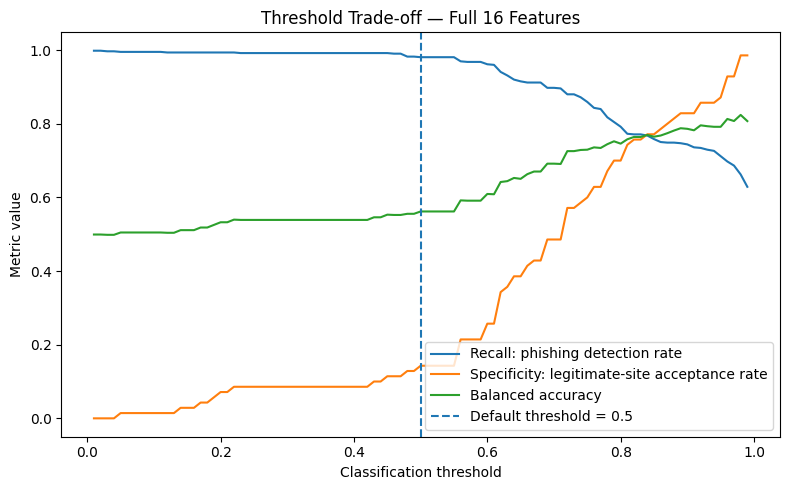

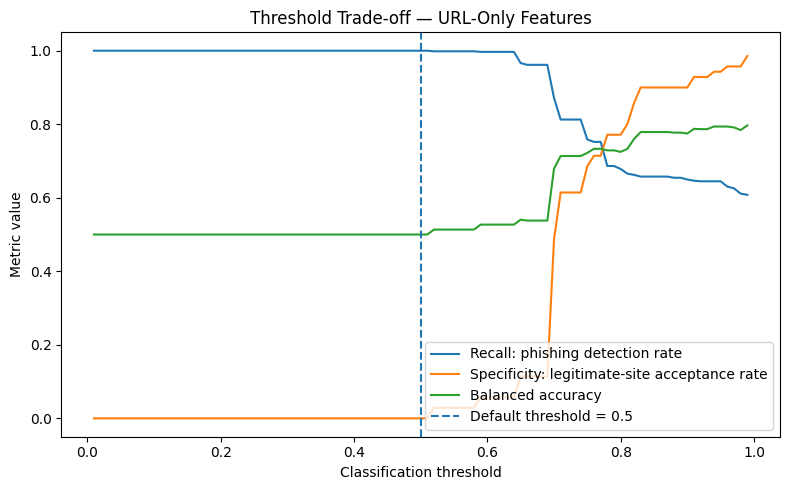

In [ ]:
import matplotlib.pyplot as plt


def plot_threshold_tradeoff(
    threshold_table,
    model_name
):
    """
    Plot the trade-off between phishing recall and legitimate-site
    specificity across classification thresholds.
    """

    plt.figure(figsize=(8, 5))

    plt.plot(
        threshold_table["Threshold"],
        threshold_table["Recall"],
        label="Recall: phishing detection rate"
    )

    plt.plot(
        threshold_table["Threshold"],
        threshold_table["Specificity"],
        label="Specificity: legitimate-site acceptance rate"
    )

    plt.plot(
        threshold_table["Threshold"],
        threshold_table["Balanced Accuracy"],
        label="Balanced accuracy"
    )

    plt.axvline(
        0.5,
        linestyle="--",
        label="Default threshold = 0.5"
    )

    plt.xlabel("Classification threshold")
    plt.ylabel("Metric value")
    plt.title(f"Threshold Trade-off — {model_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_threshold_tradeoff(
    full_threshold_table,
    "Full 16 Features"
)

plot_threshold_tradeoff(
    url_threshold_table,
    "URL-Only Features"
)

In [ ]:
def train_final_model_and_compare_thresholds(
    model_name,
    selected_features,
    selected_threshold
):
    """
    Retrain XGBoost using the complete domain-aware training set.
    Compare the default threshold with the threshold selected using
    validation data only.
    """

    final_model = XGBClassifier(
        learning_rate=0.4,
        max_depth=7,
        n_estimators=xgb_rounds,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )

    final_model.fit(
        domain_train_full[selected_features],
        domain_train_full["Label"]
    )

    test_scores = final_model.predict_proba(
        domain_test_full[selected_features]
    )[:, 1]

    default_result = calculate_threshold_metrics(
        y_true=domain_test_full["Label"],
        probability_scores=test_scores,
        threshold=0.50
    )

    tuned_result = calculate_threshold_metrics(
        y_true=domain_test_full["Label"],
        probability_scores=test_scores,
        threshold=float(selected_threshold)
    )

    default_result["Model"] = model_name
    default_result["Threshold Selection"] = "Default threshold"

    tuned_result["Model"] = model_name
    tuned_result["Threshold Selection"] = "Validation-selected threshold"

    return (
        final_model,
        test_scores,
        pd.DataFrame([
            default_result,
            tuned_result
        ])
    )


full_final_model, full_test_scores, full_threshold_test_results = (
    train_final_model_and_compare_thresholds(
        model_name="XGBoost — Full 16 Features",
        selected_features=feature_columns,
        selected_threshold=full_best_threshold["Threshold"]
    )
)

url_final_model, url_test_scores, url_threshold_test_results = (
    train_final_model_and_compare_thresholds(
        model_name="XGBoost — URL-Only Features",
        selected_features=url_only_features,
        selected_threshold=url_best_threshold["Threshold"]
    )
)

threshold_test_comparison = pd.concat(
    [
        full_threshold_test_results,
        url_threshold_test_results
    ],
    ignore_index=True
)

threshold_test_comparison = threshold_test_comparison[
    [
        "Model",
        "Threshold Selection",
        "Threshold",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "False Positive Rate",
        "F1",
        "F2",
        "MCC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

display(
    threshold_test_comparison.round(3)
)

threshold_test_comparison.to_csv(
    "threshold_test_comparison.csv",
    index=False
)

print("Saved: threshold_test_comparison.csv")

,Model,Threshold Selection,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,False Positive Rate,F1,F2,MCC,TN,FP,FN,TP
0,XGBoost — Full 16 Features,Default threshold,0.50,0.875,0.552,0.883,0.988,0.116,0.884,0.932,0.965,0.222,13,99,9,744
1,XGBoost — Full 16 Features,Validation-selected threshold,0.98,0.686,0.789,0.984,0.649,0.929,0.071,0.782,0.697,0.392,104,8,264,489
2,XGBoost — URL-Only Features,Default threshold,0.50,0.868,0.499,0.870,0.997,0.000,1.000,0.929,0.969,-0.019,0,112,2,751
3,XGBoost — URL-Only Features,Validation-selected threshold,0.99,0.636,0.779,0.993,0.586,0.973,0.027,0.737,0.638,0.375,109,3,312,441


Saved: threshold_test_comparison.csv


# Error Analysis

The strongest balanced configuration is the full 16-feature XGBoost model with
a threshold of 0.98, selected using a separate domain-aware validation set.

This section examines model failures:
- False Positives: legitimate websites incorrectly classified as phishing.
- False Negatives: phishing websites incorrectly classified as legitimate.

The processed dataset stores the extracted domain but does not preserve the
complete original URL. Therefore, the analysis can identify domain-level and
feature-level patterns, but it cannot inspect every original path, query string,
or redirect chain.

In [ ]:
# ---------------------------------------------------------
# Build the error-analysis table
# ---------------------------------------------------------

selected_threshold = float(
    full_best_threshold["Threshold"]
)

error_analysis_data = domain_test_full.copy()

error_analysis_data["Phishing_Score"] = full_test_scores

error_analysis_data["Prediction"] = (
    error_analysis_data["Phishing_Score"]
    >= selected_threshold
).astype(int)

conditions = [
    (
        (error_analysis_data["Label"] == 0)
        & (error_analysis_data["Prediction"] == 0)
    ),
    (
        (error_analysis_data["Label"] == 0)
        & (error_analysis_data["Prediction"] == 1)
    ),
    (
        (error_analysis_data["Label"] == 1)
        & (error_analysis_data["Prediction"] == 0)
    ),
    (
        (error_analysis_data["Label"] == 1)
        & (error_analysis_data["Prediction"] == 1)
    )
]

outcomes = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]

error_analysis_data["Outcome"] = np.select(
    conditions,
    outcomes,
    default="Unknown"
)

print("Selected threshold:", selected_threshold)

print("\nOutcome counts:")
print(
    error_analysis_data["Outcome"]
    .value_counts()
)

print("\nOutcome percentages:")
print(
    error_analysis_data["Outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Selected threshold: 0.98

Outcome counts:
Outcome
True Positive     489
False Negative    264
True Negative     104
False Positive      8
Name: count, dtype: int64

Outcome percentages:
Outcome
True Positive     56.53
False Negative    30.52
True Negative     12.02
False Positive     0.92
Name: proportion, dtype: float64


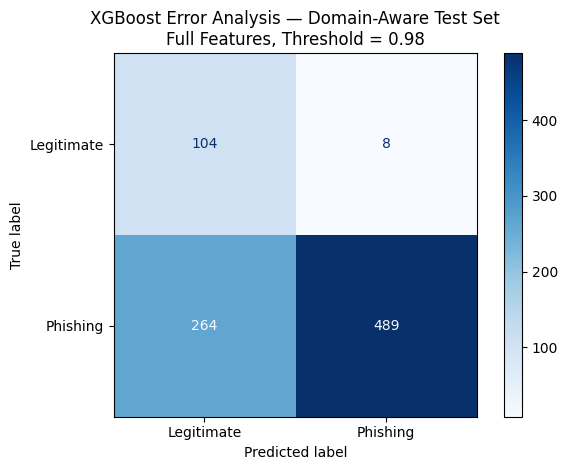

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    error_analysis_data["Label"],
    error_analysis_data["Prediction"],
    labels=[0, 1],
    display_labels=["Legitimate", "Phishing"],
    cmap="Blues"
)

plt.title(
    "XGBoost Error Analysis — Domain-Aware Test Set\n"
    "Full Features, Threshold = 0.98"
)

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Display high-confidence false positives
# ---------------------------------------------------------

false_positive_examples = (
    error_analysis_data.loc[
        error_analysis_data["Outcome"]
        == "False Positive",
        [
            "Domain",
            "Phishing_Score",
            "URL_Length",
            "URL_Depth",
            "Prefix/Suffix",
            "Have_At",
            "TinyURL",
            "DNS_Record",
            "Web_Traffic",
            "Domain_Age",
            "iFrame",
            "Mouse_Over",
            "Right_Click",
            "Web_Forwards"
        ]
    ]
    .sort_values(
        by="Phishing_Score",
        ascending=False
    )
)

print("False Positive examples:")
display(false_positive_examples)


# ---------------------------------------------------------
# Display the most confidently missed phishing samples
# ---------------------------------------------------------

false_negative_examples = (
    error_analysis_data.loc[
        error_analysis_data["Outcome"]
        == "False Negative",
        [
            "Domain",
            "Phishing_Score",
            "URL_Length",
            "URL_Depth",
            "Prefix/Suffix",
            "Have_At",
            "TinyURL",
            "DNS_Record",
            "Web_Traffic",
            "Domain_Age",
            "iFrame",
            "Mouse_Over",
            "Right_Click",
            "Web_Forwards"
        ]
    ]
    .sort_values(
        by="Phishing_Score",
        ascending=True
    )
    .head(20)
)

print("\nTwenty most confidently missed phishing examples:")
display(false_negative_examples)

False Positive examples:


,Domain,Phishing_Score,URL_Length,URL_Depth,Prefix/Suffix,Have_At,TinyURL,DNS_Record,Web_Traffic,Domain_Age,iFrame,Mouse_Over,Right_Click,Web_Forwards
110,faithtap.com,0.997894,1,2,0,0,0,0,0,0,0,0,1,0
45,xvideo-jp.com,0.993495,1,4,1,0,0,0,1,0,0,0,1,0
73,shareba.com,0.993473,1,1,0,0,0,0,0,0,0,0,1,0
4,nguyentandung.org,0.993473,1,1,0,0,0,0,0,0,0,0,1,0
58,xvideo-jp.com,0.993174,1,5,1,0,0,0,1,0,0,0,1,0
81,xvideo-jp.com,0.991959,1,3,1,0,0,0,1,0,0,0,1,0
9,babal.net,0.982182,1,4,0,0,0,0,0,0,0,0,1,0
77,nguyentandung.org,0.982182,1,4,0,0,0,0,0,0,0,0,1,0



Twenty most confidently missed phishing examples:


,Domain,Phishing_Score,URL_Length,URL_Depth,Prefix/Suffix,Have_At,TinyURL,DNS_Record,Web_Traffic,Domain_Age,iFrame,Mouse_Over,Right_Click,Web_Forwards
339,frecciainox.com,0.114999,1,7,0,0,1,0,1,0,0,0,1,0
120,123formbuilder.com,0.124635,1,2,0,0,0,0,1,1,0,0,1,0
848,bravodigital.cloud,0.214822,1,8,0,0,0,1,1,1,0,0,1,1
256,320381dbf7cd2f31c04baa6b36e1c682.webredirect.org,0.264747,1,1,0,0,0,0,1,0,1,1,1,1
301,deganplasaan.ga,0.283058,1,1,0,0,0,0,1,1,1,1,1,1
824,bravodigital.cloud,0.343275,1,9,0,0,0,1,1,1,0,0,1,1
745,casonahartfordct.com,0.363682,1,4,0,0,1,0,1,1,0,0,1,0
473,tokokainbandung.com,0.434405,1,10,0,0,0,1,1,1,0,1,1,0
119,greatescapesworkshop.com,0.442995,1,8,0,1,0,0,1,1,0,0,1,0
750,porezi.rs,0.511862,1,4,0,0,0,0,0,1,0,0,1,0


In [ ]:
# ---------------------------------------------------------
# Compare mean feature values by outcome
# ---------------------------------------------------------

outcome_feature_means = (
    error_analysis_data
    .groupby("Outcome")[feature_columns]
    .mean()
    .transpose()
)

display(
    outcome_feature_means.round(3)
)

Outcome,False Negative,False Positive,True Negative,True Positive
Have_IP,0.008,0.000,0.000,0.012
Have_At,0.049,0.000,0.000,0.055
URL_Length,1.000,1.000,1.000,0.227
URL_Depth,4.068,3.000,3.019,1.926
Redirection,0.034,0.000,0.010,0.012
https_Domain,0.000,0.000,0.000,0.000
TinyURL,0.057,0.000,0.058,0.106
Prefix/Suffix,0.027,0.375,0.010,0.243
DNS_Record,0.083,0.000,0.173,0.092
Web_Traffic,0.852,0.375,0.923,0.785


In [ ]:
# ---------------------------------------------------------
# Compare False Positives with correctly allowed legitimate rows
# ---------------------------------------------------------

false_positive_difference = (
    outcome_feature_means["False Positive"]
    - outcome_feature_means["True Negative"]
)

false_positive_pattern_table = (
    false_positive_difference
    .to_frame(
        "False Positive mean - True Negative mean"
    )
    .assign(
        **{
            "Absolute difference":
            false_positive_difference.abs()
        }
    )
    .sort_values(
        by="Absolute difference",
        ascending=False
    )
)

print(
    "Largest feature differences between False Positives "
    "and True Negatives:"
)

display(
    false_positive_pattern_table.head(10).round(3)
)

Largest feature differences between False Positives and True Negatives:


,False Positive mean - True Negative mean,Absolute difference
Web_Traffic,-0.548,0.548
Domain_Age,-0.538,0.538
Prefix/Suffix,0.365,0.365
Domain_End,0.192,0.192
DNS_Record,-0.173,0.173
Web_Forwards,-0.135,0.135
iFrame,-0.058,0.058
TinyURL,-0.058,0.058
Mouse_Over,-0.058,0.058
URL_Depth,-0.019,0.019


In [ ]:
# ---------------------------------------------------------
# Compare missed phishing rows with correctly detected phishing rows
# ---------------------------------------------------------

false_negative_difference = (
    outcome_feature_means["False Negative"]
    - outcome_feature_means["True Positive"]
)

false_negative_pattern_table = (
    false_negative_difference
    .to_frame(
        "False Negative mean - True Positive mean"
    )
    .assign(
        **{
            "Absolute difference":
            false_negative_difference.abs()
        }
    )
    .sort_values(
        by="Absolute difference",
        ascending=False
    )
)

print(
    "Largest feature differences between False Negatives "
    "and True Positives:"
)

display(
    false_negative_pattern_table.head(10).round(3)
)

Largest feature differences between False Negatives and True Positives:


,False Negative mean - True Positive mean,Absolute difference
URL_Depth,2.142,2.142
URL_Length,0.773,0.773
Prefix/Suffix,-0.217,0.217
Web_Traffic,0.067,0.067
TinyURL,-0.050,0.050
Web_Forwards,-0.047,0.047
iFrame,-0.045,0.045
Domain_Age,0.025,0.025
Redirection,0.022,0.022
Mouse_Over,-0.018,0.018


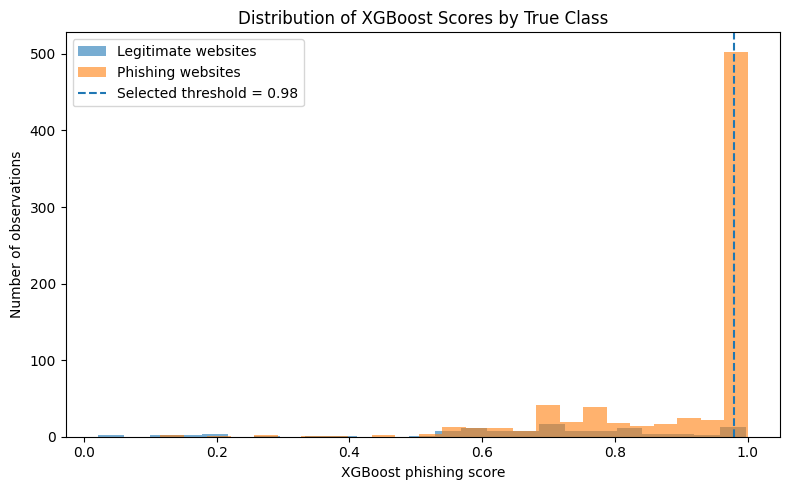

In [ ]:
# ---------------------------------------------------------
# Visualize phishing scores by true class
# ---------------------------------------------------------

legitimate_scores = error_analysis_data.loc[
    error_analysis_data["Label"] == 0,
    "Phishing_Score"
]

phishing_scores = error_analysis_data.loc[
    error_analysis_data["Label"] == 1,
    "Phishing_Score"
]

plt.figure(figsize=(8, 5))

plt.hist(
    legitimate_scores,
    bins=25,
    alpha=0.6,
    label="Legitimate websites"
)

plt.hist(
    phishing_scores,
    bins=25,
    alpha=0.6,
    label="Phishing websites"
)

plt.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Selected threshold = {selected_threshold:.2f}"
)

plt.xlabel("XGBoost phishing score")
plt.ylabel("Number of observations")
plt.title("Distribution of XGBoost Scores by True Class")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# Save error-analysis outputs
# ---------------------------------------------------------

error_analysis_data.to_csv(
    "xgboost_tuned_threshold_error_analysis.csv",
    index=False
)

false_positive_pattern_table.to_csv(
    "false_positive_feature_patterns.csv"
)

false_negative_pattern_table.to_csv(
    "false_negative_feature_patterns.csv"
)

print("Saved error-analysis CSV files.")

Saved error-analysis CSV files.
